# Práctico 2 — Análisis Exploratorio y Curación de Datos
## DiploDatos 2026 · Ciencia de Datos Aplicada al Fútbol

**Objetivos de aprendizaje**
- Realizar un EDA riguroso sobre datos de eventos de fútbol
- Detectar y tratar problemas de calidad: valores faltantes, outliers, inconsistencias
- Convertir eventos de Wyscout al formato SPADL (Soccer Player Action Description Language)
- Construir features contextuales y posicionales para modelado
- Entender el sesgo de selección en datos deportivos

**Referencia clave**: Decroos et al. (2019) *Actions Speak Louder than Goals: Valuing Player Actions in Football*

---

### **Entregable 4/9/26**: 
- Notebook con EDA completo
- Reporte de decisiones de curación 
- PPT con donde se muestren los principales hallazgos encontrados en los dos primeros TPs.

---

In [1]:
import json
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import kstest, normaltest
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba
import plotly.express as px
import plotly.graph_objects as go
#from scipy.stats import gaussian_kde
from mplsoccer import Pitch, VerticalPitch, FontManager
from mplsoccer.utils import FontManager
import sys
import time
from pathlib import Path
from typing import List, Dict, Callable, Optional, Union
import pyarrow.parquet as pq
from io import BytesIO

# socceraction: librería oficial para SPADL
import socceraction.spadl as spadl
from socceraction.data.wyscout import WyscoutLoader

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

# Configuración visual
PALETTE = sns.color_palette('Set2')
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)

# -- CONFIGURACION DE RUTAS --
DATA_DIR = Path('../data')
DATASET_DIR = DATA_DIR / 'events'
print(f'Data dir: {DATA_DIR}')
print(f'Dataset dir: {DATASET_DIR}')
print('✓ Librerías importadas correctamente')

Data dir: ..\data
Dataset dir: ..\data\events
✓ Librerías importadas correctamente


## 1. Carga completa del dataset multliga

En este práctico trabajamos con **todas las ligas** para tener una base más robusta.

In [2]:
#La siguiente celda enumera las competiciones que se incluirán en el conjunto de datos.
#Descomente las competiciones que desee incluir en su conjunto de datos.

competitions = [
    'England',
#    'France',
#    'Germany',
    'Italy',
    'Spain',
#    'European Championship',
#  'World Cup'
]

### 1.1 Lectura Optimizada de eventos desde archivos Parquet

In [3]:
def load_events_parquet(
    parquet_path: Path, 
    columns: Optional[List[str]] = None, 
    filters: Optional[List[tuple]] = None
) -> pd.DataFrame:
    """
    Carga eventos desde un archivo Parquet de forma optimizada.
    
    Parametros
    ----------
    parquet_path : Path al archivo .parquet.
    columns : Subconjunto de columnas a leer (None = todas).
    filters : Lista de tuplas para filtrar antes de cargar.
              Ejemplo: [('eventName', '==', 'Shot')]
    """
    print(f'[INFO] Cargando {parquet_path.name}...')
    t0 = time.time()
    
    # Leer con pyarrow + pandas para mejor rendimiento y control de tipos
    df = pd.read_parquet(
        parquet_path, 
        columns=columns, 
        filters=filters, 
        engine='pyarrow'
    )
    
    elapsed = time.time() - t0
    print(f'[INFO] Cargado en {elapsed:.2f}s | Filas: {len(df):,} | Columnas: {len(df.columns)}')
    return df


In [4]:
dfs=[]
for competition in competitions:
    competition_name = competition.replace(' ', '_')
    file_events = f'events_{competition_name}.parquet'
    print(f"file: {file_events}")
    FILE_PATH=DATASET_DIR / file_events
    print(f"file path: {FILE_PATH}")
    #json_events = read_json_file(file_events)
    data = load_events_parquet(
                            FILE_PATH,
                            columns= ['eventId', 'subEventName', 'tags', 'playerId', 'positions', 'matchId', 'eventName', 'teamId', 'matchPeriod', 'eventSec', 'subEventId', 'id']
                        )
    #df_all = pd.DataFrame(data)
    data['league'] = competition
    dfs.append(data)#df_all)
    print(f'  {competition}: {len(data):>8,} eventos')
    del data
df_all = pd.concat(dfs)
del dfs
print(f'\nTotal: {len(df_all):,} eventos | {df_all["league"].nunique()} ligas')

file: events_England.parquet
file path: ..\data\events\events_England.parquet
[INFO] Cargando events_England.parquet...
[INFO] Cargado en 4.04s | Filas: 643,150 | Columnas: 12
  England:  643,150 eventos
file: events_Italy.parquet
file path: ..\data\events\events_Italy.parquet
[INFO] Cargando events_Italy.parquet...
[INFO] Cargado en 3.51s | Filas: 647,372 | Columnas: 12
  Italy:  647,372 eventos
file: events_Spain.parquet
file path: ..\data\events\events_Spain.parquet
[INFO] Cargando events_Spain.parquet...
[INFO] Cargado en 3.76s | Filas: 628,659 | Columnas: 12
  Spain:  628,659 eventos

Total: 1,919,181 eventos | 3 ligas


### 1.2 Lectura de archivos de partidos

In [5]:

def read_json_file(filename):
    with open(filename, 'rb') as json_file:
        return BytesIO(json_file.read()).getvalue().decode('unicode_escape')

def load_json(path: str) -> pd.DataFrame:
    print(path)
    data = pd.read_json(str(path))
    #data=read_json_file(path)
    return data#pd.read_json(data)


In [6]:
dfs_matches = []
for competition in competitions:
    competition_name = competition.replace(' ', '_')
    file_matches = f'matches/matches_{competition_name}.json'
    #print(f"file: {file_matches}")
    FILE_PATH=DATA_DIR / file_matches
    print(f"file path: {FILE_PATH}")
    #json_matches = read_json_file(FILE_PATH)
    data = load_json(FILE_PATH)#pd.read_json(json_matches)
    dfs_matches.append(data)
    del data
df_matches = pd.concat(dfs_matches)
del dfs_matches
df_matches.head(3)

file path: ..\data\matches\matches_England.json
..\data\matches\matches_England.json
file path: ..\data\matches\matches_Italy.json
..\data\matches\matches_Italy.json
file path: ..\data\matches\matches_Spain.json
..\data\matches\matches_Spain.json


,status,roundId,gameweek,teamsData,seasonId,dateutc,winner,venue,wyId,label,date,referees,duration,competitionId
0,Played,4405654,38,"{'1646': {'scoreET': 0, 'coachId': 8880, 'side...",181150,2018-05-13 14:00:00,1659,Turf Moor,2500089,"Burnley - AFC Bournemouth, 1 - 2","May 13, 2018 at 4:00:00 PM GMT+2","[{'refereeId': 385705, 'role': 'referee'}, {'r...",Regular,364
1,Played,4405654,38,"{'1628': {'scoreET': 0, 'coachId': 8357, 'side...",181150,2018-05-13 14:00:00,1628,Selhurst Park,2500090,"Crystal Palace - West Bromwich Albion, 2 - 0","May 13, 2018 at 4:00:00 PM GMT+2","[{'refereeId': 381851, 'role': 'referee'}, {'r...",Regular,364
2,Played,4405654,38,"{'1609': {'scoreET': 0, 'coachId': 7845, 'side...",181150,2018-05-13 14:00:00,1609,The John Smith's Stadium,2500091,"Huddersfield Town - Arsenal, 0 - 1","May 13, 2018 at 4:00:00 PM GMT+2","[{'refereeId': 384965, 'role': 'referee'}, {'r...",Regular,364


### 1.3 Lectura de archivos de jugadores y equipos

In [7]:
# Carga de metadata de equipos
df_teams = load_json(DATA_DIR / 'teams.json')
df_teams

..\data\teams.json


,city,name,wyId,officialName,area,type
0,Newcastle upon Tyne,Newcastle United,1613,Newcastle United FC,"{'name': 'England', 'id': '0', 'alpha3code': '...",club
1,Vigo,Celta de Vigo,692,Real Club Celta de Vigo,"{'name': 'Spain', 'id': '724', 'alpha3code': '...",club
2,Barcelona,Espanyol,691,Reial Club Deportiu Espanyol,"{'name': 'Spain', 'id': '724', 'alpha3code': '...",club
3,Vitoria-Gasteiz,Deportivo Alav\u00e9s,696,Deportivo Alav\u00e9s,"{'name': 'Spain', 'id': '724', 'alpha3code': '...",club
4,Valencia,Levante,695,Levante UD,"{'name': 'Spain', 'id': '724', 'alpha3code': '...",club
...,...,...,...,...,...,...
137,Las Rozas,Spain,1598,Spain,"{'name': 'Spain', 'id': 724, 'alpha3code': 'ES...",national
138,Beograd,Serbia,17322,Serbia,"{'name': 'Serbia', 'id': 688, 'alpha3code': 'S...",national
139,Bern,Switzerland,6697,Switzerland,"{'name': 'Switzerland', 'id': 756, 'alpha3code...",national
140,Warszawa,Poland,13869,Poland,"{'name': 'Poland', 'id': 616, 'alpha3code': 'P...",national


In [8]:
# Carga de metadata de jugadores
df_players = load_json(DATA_DIR / 'players.json')
df_players.head(3)

..\data\players.json


,passportArea,weight,firstName,middleName,lastName,currentTeamId,birthDate,height,role,birthArea,wyId,foot,shortName,currentNationalTeamId
0,"{'name': 'Turkey', 'id': '792', 'alpha3code': ...",78,Harun,,Tekin,4502,1989-06-17,187,"{'code2': 'GK', 'code3': 'GKP', 'name': 'Goalk...","{'name': 'Turkey', 'id': '792', 'alpha3code': ...",32777,right,H. Tekin,4687
1,"{'name': 'Senegal', 'id': '686', 'alpha3code':...",73,Malang,,Sarr,3775,1999-01-23,182,"{'code2': 'DF', 'code3': 'DEF', 'name': 'Defen...","{'name': 'France', 'id': '250', 'alpha3code': ...",393228,left,M. Sarr,4423
2,"{'name': 'France', 'id': '250', 'alpha3code': ...",72,Over,,Mandanda,3772,1998-10-26,176,"{'code2': 'GK', 'code3': 'GKP', 'name': 'Goalk...","{'name': 'France', 'id': '250', 'alpha3code': ...",393230,,O. Mandanda,null


## 2. EDA — Análisis Exploratorio de Datos

### 2.1 Estructura y tipos de datos

In [9]:
print('=== INFO GENERAL DEL DATASET ===')
print(f'Shape: {df_all.shape}')
print(f'Memoria: {df_all.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print()
print('Tipos de datos:')
print(df_all.dtypes)

=== INFO GENERAL DEL DATASET ===
Shape: (1919181, 13)
Memoria: 1091.9 MB

Tipos de datos:
eventId           int64
subEventName     object
tags             object
playerId          int64
positions        object
matchId           int64
eventName        object
teamId            int64
matchPeriod      object
eventSec        float64
subEventId       object
id                int64
league           object
dtype: object


### 2.2 Análisis de valores faltantes

In [10]:
def analyze_missing(df):
    """Genera reporte completo de valores faltantes."""
    missing = df.isnull().sum()
    pct = (missing / len(df) * 100).round(2)
    report = pd.DataFrame({
        'missing_count': missing,
        'missing_pct': pct,
        'dtype': df.dtypes
    }).sort_values('missing_pct', ascending=False)
    return report[report['missing_count'] > 0]

missing_report = analyze_missing(df_all)
print('Columnas con valores faltantes:')
print(missing_report.to_string())

Columnas con valores faltantes:
Empty DataFrame
Columns: [missing_count, missing_pct, dtype]
Index: []


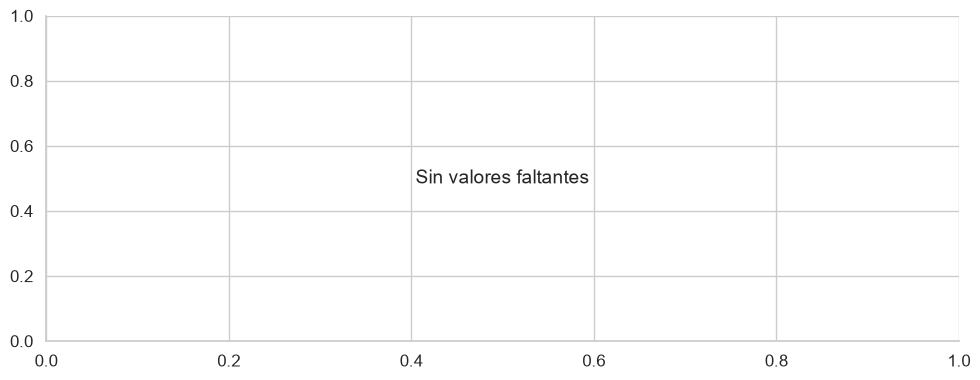

In [11]:
# Visualización del patrón de missings
fig, ax = plt.subplots(figsize=(10, 4))
cols_with_missing = missing_report[missing_report['missing_pct'] > 0].index
if len(cols_with_missing) > 0:
    missing_report[missing_report['missing_pct'] > 0]['missing_pct'].sort_values().plot(
        kind='barh', ax=ax, color='#378ADD'
    )
    ax.set_xlabel('% de valores faltantes')
    ax.set_title('Análisis de valores faltantes por columna')
    ax.axvline(x=5, color='orange', linestyle='--', label='Umbral 5%')
    ax.axvline(x=20, color='red', linestyle='--', label='Umbral 20%')
    ax.legend()
else:
    ax.text(0.5, 0.5, 'Sin valores faltantes', ha='center', va='center', fontsize=14)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

### 2.3 Extracción y análisis de coordenadas.

In [12]:
def parse_positions(pos_list):
    """Extrae coordenadas x,y del campo (0-100) desde el campo 'positions'."""
    if isinstance(pos_list, list) and len(pos_list) >= 1:
        return pos_list[0].get('x', np.nan), pos_list[0].get('y', np.nan)
    return np.nan, np.nan

def parse_end_positions(pos_list):
    """Extrae posición final de la acción."""
    if isinstance(pos_list, list) and len(pos_list) >= 2:
        return pos_list[1].get('x', np.nan), pos_list[1].get('y', np.nan)
    return np.nan, np.nan

def parse_tags(tag_list):
    """Extrae lista de IDs de tags."""
    if isinstance(tag_list.tolist(), list):
        return [t.get('id') for t in tag_list.tolist()]
    return []


In [13]:

# Aplicamos parseo vectorizado
df_all[['x', 'y']] = df_all['positions'].apply(
    lambda p: pd.Series(parse_positions(p.tolist()))
)
df_all[['end_x', 'end_y']] = df_all['positions'].apply(
    lambda p: pd.Series(parse_end_positions(p.tolist()))
)
df_all['tag_ids'] = df_all['tags'].apply(parse_tags)


#### Auditoría de coordenadas

In [14]:
print('=== AUDITORÍA DE COORDENADAS ===')
print(f'Eventos con x válido: {df_all["x"].notna().sum():,} ({df_all["x"].notna().mean():.1%})')
print(f'Eventos con y válido: {df_all["y"].notna().sum():,} ({df_all["y"].notna().mean():.1%})')
print(f'Rango x: [{df_all["x"].min():.1f}, {df_all["x"].max():.1f}]')
print(f'Rango y: [{df_all["y"].min():.1f}, {df_all["y"].max():.1f}]')

# Eventos fuera de rango (0-100)
out_of_bounds = df_all[
    (df_all['x'].notna()) & 
    ((df_all['x'] < 0) | (df_all['x'] > 100) | (df_all['y'] < 0) | (df_all['y'] > 100))
]
print(f'\nEventos con coordenadas fuera de rango: {len(out_of_bounds)} ({len(out_of_bounds)/len(df_all):.2%})')

=== AUDITORÍA DE COORDENADAS ===
Eventos con x válido: 1,919,181 (100.0%)
Eventos con y válido: 1,919,181 (100.0%)
Rango x: [-1.0, 100.0]
Rango y: [0.0, 100.0]

Eventos con coordenadas fuera de rango: 1 (0.00%)


In [15]:
out_of_bounds

,eventId,subEventName,tags,playerId,positions,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id,league,x,y,end_x,end_y,tag_ids
140843,7,Touch,[],166534,"[{'x': -1, 'y': 47}, {'x': 69, 'y': 12}]",2576042,Others on the ball,3162,2H,2753.1903,72,198907641,Italy,-1,47,69.0000,12.0000,[]


##### Se detecta un único caso en la liga Italiana, y siendo un evento "Others on the ball" y "Touch" en subEventName, en el segundo tiempo (45.89 minutos), la decisión es eliminar el registro. Dcoumentación de la decisión:

Problema: coordenada x=-1 fuera del rango válido (0-100).
Registros afectados: 1 de 1.919.181 (0.00005%).
Decisión de curación: eliminar. Dado que es "Others on the ball" (acción sin relevancia táctica clara).
Alternativa considerada: imputar con la mediana de x para ese tipo de evento, pero con un solo caso no vale la pena.

#### Distribución espacial de los eventos — heatmap 2D

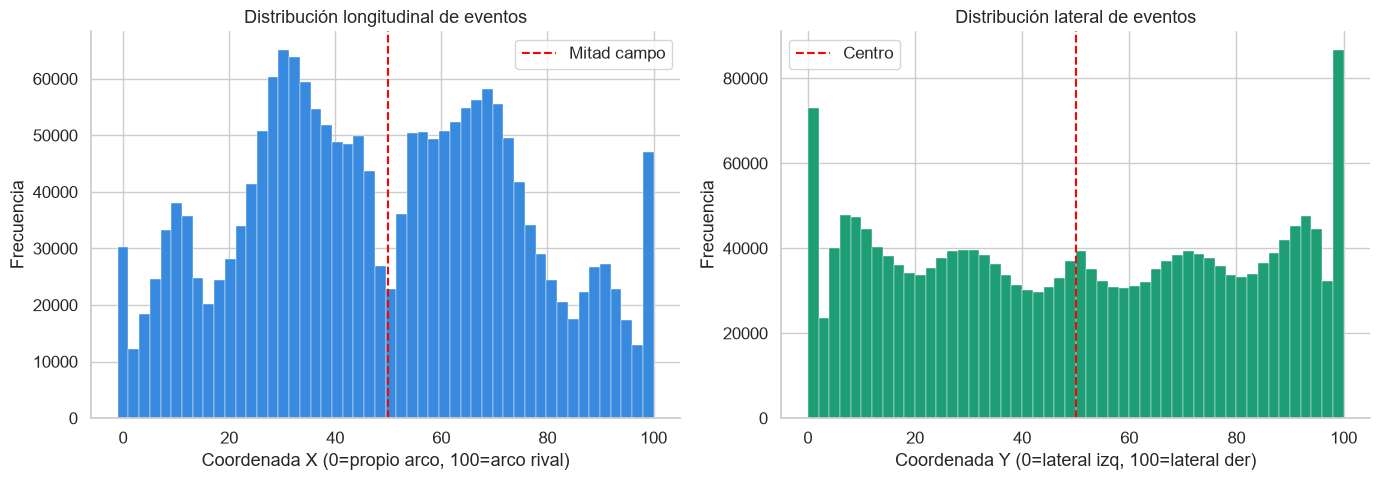

In [16]:

df_valid = df_all.dropna(subset=['x','y'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución x
axes[0].hist(df_valid['x'], bins=50, color='#378ADD', edgecolor='white', linewidth=0.3)
axes[0].set_xlabel('Coordenada X (0=propio arco, 100=arco rival)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución longitudinal de eventos')
axes[0].axvline(50, color='red', linestyle='--', label='Mitad campo')
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

# Distribución y
axes[1].hist(df_valid['y'], bins=50, color='#1D9E75', edgecolor='white', linewidth=0.3)
axes[1].set_xlabel('Coordenada Y (0=lateral izq, 100=lateral der)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución lateral de eventos')
axes[1].axvline(50, color='red', linestyle='--', label='Centro')
axes[1].legend()
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

## Análisis parciales de los resultados de distribución de eventos. 

Existen algunos resultados coherentes: los picos en X entre 30-40; y entre 55-75 aproximadamente son consistentes con las zonas de gestación en la mitad propia/presión del rival y con la fase de ataque y defensa del rival. El mediocampo es una zona de transición. Si llama un poco más la atención las colas cargadas en X=0 y X=100, que si bien pueden ser consistentes con saques de arco, corners, goles, vale la pena examinar más.
Si es más llamativa la concentración en Y=0 e Y=100, que si bien pueden representar saques de banda y corners, la concentración es notable y conviene analizarla. 

### ¿Son placeholders sistemáticos de Wyscout para eventos sin coordenada precisa?

In [17]:
# Ver los eventos en cada borde

for val, eje in [(0, 'x'), (100, 'x'), (0, 'y'), (100, 'y')]:
    mask = df_all[eje] == val
    print(f"\n=== {eje}={val} — {mask.sum():,} eventos ({mask.mean():.1%}) ===")
    print(df_all[mask]['eventName'].value_counts().head(10))


=== x=0 — 26,522 eventos (1.4%) ===
eventName
Interruption               11729
Free Kick                   8423
Save attempt                4615
Goalkeeper leaving line     1608
Others on the ball            73
Pass                          49
Duel                          24
Foul                           1
Name: count, dtype: int64

=== x=100 — 39,941 eventos (2.1%) ===
eventName
Free Kick                  21720
Interruption               10350
Save attempt                5705
Goalkeeper leaving line     2026
Pass                          93
Duel                          23
Others on the ball            12
Foul                           6
Shot                           4
Offside                        2
Name: count, dtype: int64

=== y=0 — 69,295 eventos (3.6%) ===
eventName
Free Kick                  37373
Interruption               24977
Save attempt                4615
Goalkeeper leaving line     1608
Pass                         533
Others on the ball            98
Duel         

In [18]:
# Ver si hay diferencias en la concentración de eventos en los bordes, por ligas

for liga in df_all['league'].unique():
    sub = df_all[df_all['league'] == liga]
    borde_y = ((sub['y'] == 0) | (sub['y'] == 100)).mean()
    borde_x = ((sub['x'] == 0) | (sub['x'] == 100)).mean()
    print(f"{liga}: borde_y={borde_y:.1%}, borde_x={borde_x:.1%}")

England: borde_y=7.6%, borde_x=3.4%
Italy: borde_y=7.4%, borde_x=3.5%
Spain: borde_y=7.4%, borde_x=3.4%


#### Conclusiones 

Los 2 ejercicios realizados son consistentes y coherentes: 

1. Los eventos en los bordes son interrupciones (salidas del campo), freekicks que concentra saques laterales, corners y tiros libres propiamente dichos) o salvadas del arquero entre los más frecuentes.
2. Comparación entre ligas: la distribución es identica, por lo que no parecieran placeholders particulares según la liga.

#### Conclusión general: No se trata de eventos anómalos que deban eliminarse o imputarse. Decisión final: conservación de eventos en coordenadas extremas (x=0, x=100, y=0, y=100).

### 2.4 Detección de outliers y anomalías en los datos
En eventos de fútbol, los valores atípicos suelen originarse por:
1. **Errores de registro o medición:** Coordenadas fuera de escala o valores temporales anómalos (detectables con métodos estadísticos como IQR y Z-Score).
2. **Partidos incompletos o truncados:** Partidos con una cantidad inusualmente baja o excesiva de eventos registrados respecto a la media.
3. **Casos reales extremos (outliers válidos):** Jugadas excepcionales que no deben eliminarse porque forman parte del juego real.

In [19]:
def detect_outliers_iqr(series: pd.Series, factor: float = 1.5) -> pd.Series:
    """Detecta outliers usando el criterio IQR."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    return (series < lower) | (series > upper)

def detect_outliers_zscore(series: pd.Series, threshold: float = 3.0) -> pd.Series:
    """Detecta outliers usando Z-score nativo de pandas."""
    mean = series.mean()
    std = series.std(ddof=0)
    if std == 0 or pd.isna(std):
        return pd.Series(False, index=series.index)
    z = ((series - mean) / std).abs()
    return (z > threshold).fillna(False)


In [20]:
# Si ya extrajiste x e y de 'positions':
for col in ['x', 'y']:
    if col in df_all.columns:
        series = df_all[col].dropna()
        iqr_outliers = detect_outliers_iqr(series)
        z_outliers   = detect_outliers_zscore(series)
        print(f'{col}: IQR outliers={iqr_outliers.sum():,} | Z-score outliers={z_outliers.sum():,}')

print('\n=== ANÁLISIS DE PERÍODOS ===')
if 'matchPeriod' in df_all.columns and 'eventSec' in df_all.columns:
    print(df_all.groupby('matchPeriod')['eventSec'].describe())


x: IQR outliers=0 | Z-score outliers=0
y: IQR outliers=0 | Z-score outliers=0

=== ANÁLISIS DE PERÍODOS ===
                  count      mean      std    min      25%       50%  \
matchPeriod                                                            
1H          961337.0000 1360.6149 812.5093 0.0355 650.8960 1346.7117   
2H          957844.0000 1434.5381 859.6438 0.0000 681.5895 1420.7895   

                  75%       max  
matchPeriod                      
1H          2062.5143 3302.2827  
2H          2177.6327 3476.7790  


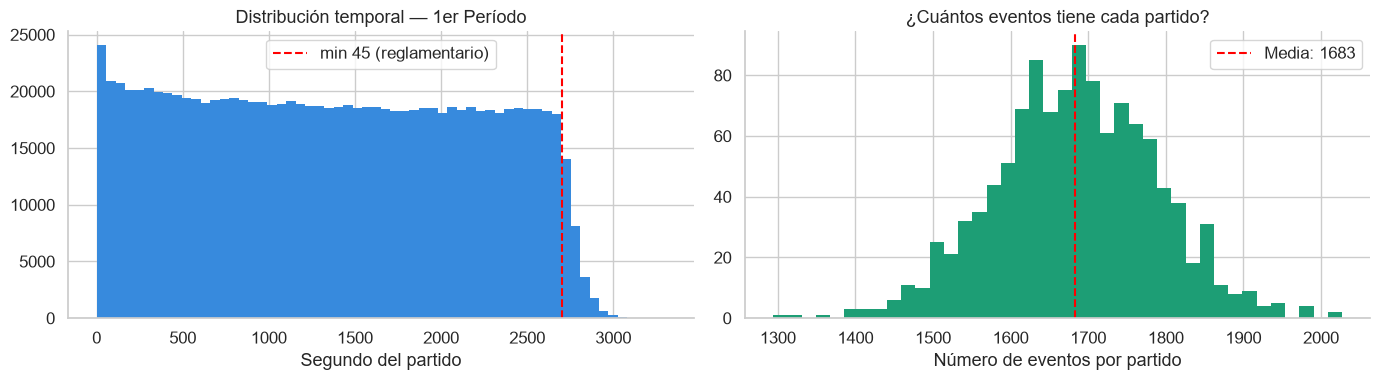

Partidos potencialmente problemáticos: 24


In [21]:
# Análisis de tiempos de eventos
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribución de segundos en el primer período
p1 = df_all[df_all['matchPeriod'] == '1H']['eventSec'].clip(0, 6000)
axes[0].hist(p1, bins=60, color='#378ADD', edgecolor='none')
axes[0].set_xlabel('Segundo del partido')
axes[0].set_title('Distribución temporal — 1er Período')
axes[0].axvline(45*60, color='red', linestyle='--', label='min 45 (reglamentario)')
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

# Número de eventos por partido — distribución
events_per_match = df_all.groupby('matchId').size()
axes[1].hist(events_per_match, bins=40, color='#1D9E75', edgecolor='none')
axes[1].set_xlabel('Número de eventos por partido')
axes[1].set_title('¿Cuántos eventos tiene cada partido?')
axes[1].axvline(events_per_match.mean(), color='red', linestyle='--', 
                label=f'Media: {events_per_match.mean():.0f}')
axes[1].legend()
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

# Partidos con muy pocos o muchos eventos (posibles problemas de datos)
q01 = events_per_match.quantile(0.01)
q99 = events_per_match.quantile(0.99)
problematic = events_per_match[(events_per_match < q01) | (events_per_match > q99)]
print(f'Partidos potencialmente problemáticos: {len(problematic)}')

### Hallazgo — Tiempo de descuento en eventSec

**Observación:** `eventSec` puede superar los 2700s (45 min × 60s) en el 1H y 
los 2700s en el 2H. Esto refleja el tiempo de descuento, que Wyscout registra 
como continuación del período (no como período separado).

**Evidencia:**
- 1H: max eventSec = 3302s (~55 min reales)
- 2H: max eventSec = 3476s (~58 min reales)

**Impacto:** no afecta al análisis de volumen ni al pipeline SPADL. Sí afecta 
a cualquier análisis temporal que asuma que 1H ⊂ [0, 2700s] o que use ventanas 
de minuto fijo (ej. Ejercicio 2 — intensidad de eventos por minuto).

**Decisión:** cuando se realice el Ejercicio 2, convertir `eventSec` 
a minuto de partido continuo antes de graficar:

```python
# Conversión a minuto continuo (pendiente para Ejercicio 2)
df_all['minute'] = df_all.apply(
    lambda r: r['eventSec'] / 60 if r['matchPeriod'] == '1H'
              else 45 + r['eventSec'] / 60,
    axis=1
)
```

Esto produce un eje de 0 a ~103 min que incluye el tiempo de descuento 
de forma natural y legible, sin truncar ni perder eventos reales.

### 2.5 Análisis de sesgo en los datos

Los datos deportivos tienen sesgos importantes que debemos documentar:
- Sesgo de equipo: los equipos más populares tienen más cobertura
- Sesgo de posición: los jugadores ofensivos tienen más eventos registrados
- Sesgo de resultado: se registran más eventos cerca de los goles

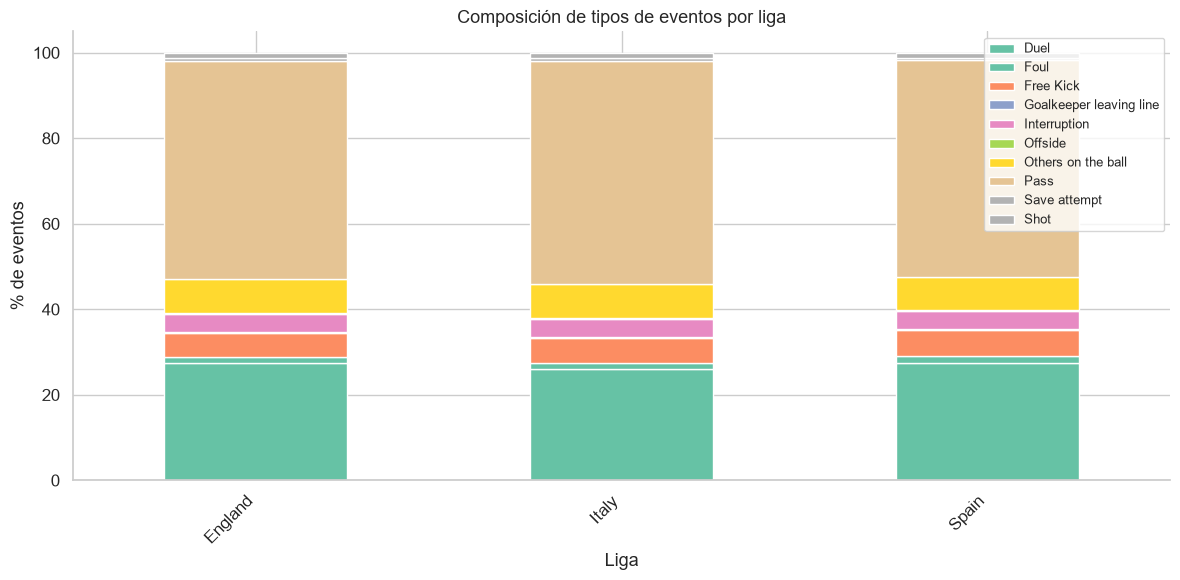


¿Son comparables los datos entre ligas? ¿Hay diferencias en la anotación?


In [22]:
# Distribución de eventos por tipo — ¿hay sesgo hacia eventos ofensivos?
event_dist = df_all.groupby(['league', 'eventName']).size().unstack(fill_value=0)
event_dist_pct = event_dist.div(event_dist.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 6))
event_dist_pct.plot(kind='bar', stacked=True, ax=ax, colormap='Set2')
ax.set_xlabel('Liga')
ax.set_ylabel('% de eventos')
ax.set_title('Composición de tipos de eventos por liga')
ax.legend(loc='upper right', fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('\n¿Son comparables los datos entre ligas? ¿Hay diferencias en la anotación?')

#### Conclusiones parciales 

¿Son comparables los datos entre ligas? 
El gráfico previo permite apreciar que no existen sesgos de registros en las 3 ligas seleccionadas, y a priori las tres fueron capturadas con los mismos criterios y la misma metodología de Wyscout.

## 3. Conversión a SPADL

SPADL (Soccer Player Action Description Language) es el formato estándar propuesto por
Decroos et al. (2019). Representa cada acción como un vector con:
- `game_id`, `period_id`, `time_seconds`: identificación temporal
- `team_id`, `player_id`: actores
- `start_x`, `start_y`, `end_x`, `end_y`: posiciones
- `action_type_id`: tipo de acción (18 tipos estandarizados)
- `bodypart_id`: parte del cuerpo usada
- `result_id`: resultado (exitoso/fallido/gol/etc)

In [23]:
# 1. Extraer los IDs únicos que realmente existen en tus eventos filtrados
# (Asegúrate de que los nombres de las columnas coincidan con los de tu df_all)
equipos_validos = df_all['teamId'].unique()
jugadores_validos = df_all['playerId'].unique()

# Opcional: Eliminar el ID '0' si existe (Wyscout usa 0 para eventos sin un jugador/equipo específico)
jugadores_validos = [pid for pid in jugadores_validos if pid != 0]

# 2. Filtrar df_teams y df_players
# (En los datos crudos de Wyscout, la columna de ID para equipos y jugadores suele ser 'wyId')
df_teams_filtrado = df_teams[df_teams['wyId'].isin(equipos_validos)]
df_players_filtrado = df_players[df_players['wyId'].isin(jugadores_validos)]

# 3. Agrupar los eventos por partido (como hicimos antes)
# (Revisa si en tu df_all la columna es 'matchId' o 'match_id')
events_dict = {match_id: df for match_id, df in df_all.groupby('matchId')}

# 4. Armar el diccionario con los datos ya limpios y filtrados
datos_wyscout = {
    "matches": df_matches,  # Este ya lo tenías filtrado
    "players": df_players_filtrado, # <-- ¡Usamos el filtrado!
    "teams": df_teams_filtrado,     # <-- ¡Usamos el filtrado!
    "events": events_dict
}


In [24]:
from socceraction.spadl.config import actiontypes, bodyparts, results

In [25]:
from wyscout import (
    convert_games, 
    convert_players, 
    convert_teams, 
    get_player_games, 
    convert_actions
)

In [26]:
import tqdm

def convert_to_spadl_memory(wyscout_data, actiontypes, bodyparts, results):
    """
    Convierte datos de Wyscout a SPADL usando DataFrames en memoria.
    
    Parámetros:
    wyscout_data: dict que contiene las claves 'matches', 'players', 'teams' 
                  y un diccionario de 'events' agrupado por ID de partido.
    """
    # Diccionario que guardará todos nuestros DataFrames convertidos
    spadl_data = {}

    print("...Inserting actiontypes, bodyparts, results")
    spadl_data["actiontypes"] = pd.DataFrame(
        list(enumerate(actiontypes)), columns=["type_id", "type_name"]
    )
    spadl_data["bodyparts"] = pd.DataFrame(
        list(enumerate(bodyparts)), columns=["bodypart_id", "bodypart_name"]
    )
    spadl_data["results"] = pd.DataFrame(
        list(enumerate(results)), columns=["result_id", "result_name"]
    )

    print("...Converting matches, players, teams")
    # Nota: Asegúrate de tener importadas/definidas convert_games, convert_players, convert_teams
    matches = wyscout_data["matches"]
    games = convert_games(matches)
    
    spadl_data["games"] = games
    spadl_data["players"] = convert_players(wyscout_data["players"])
    spadl_data["teams"] = convert_teams(wyscout_data["teams"])

    print("...Generating player_games")
    player_games = []
    for match in tqdm.tqdm(list(matches.itertuples()), unit="game"):
        # Asume que guardaste los eventos en un diccionario donde la clave es el ID del partido
        events = wyscout_data["events"][match.wyId] 
        
        pg = get_player_games(match, events)
        player_games.append(pg)
        
    spadl_data["player_games"] = pd.concat(player_games)

    print("...Converting events to actions")
    spadl_data["actions"] = {} # Sub-diccionario para las acciones de cada partido
    
    for game in tqdm.tqdm(list(games.itertuples()), unit="game"):
        events = wyscout_data["events"][game.game_id]
        actions = convert_actions(events, game.home_team_id)
        
        # Guardamos las acciones en memoria, usando el ID del partido como clave
        spadl_data["actions"][game.game_id] = actions
        
    return spadl_data

In [27]:

# 5. Ejecutar la función
datos_spadl = convert_to_spadl_memory(datos_wyscout, actiontypes, bodyparts, results)

...Inserting actiontypes, bodyparts, results
...Converting matches, players, teams
...Generating player_games


100%|██████████| 1140/1140 [00:02<00:00, 486.88game/s]


...Converting events to actions


100%|██████████| 1140/1140 [10:18<00:00,  1.84game/s]


### Decisión 4 — Fix de compatibilidad wyscout.py con pandas 3.0

**Problema identificado:** el archivo `wyscout.py` del tutor fue escrito para 
pandas 2.x y presenta dos incompatibilidades con pandas 3.0:

1. `make_new_positions`: acceso posicional `x[0]`, `x[1]` en `.apply(axis=1)` 
   — en pandas 3.0 las filas ya no son indexables por posición entera, solo 
   por nombre de columna. Corregido a `x["id"]`, `x["positions"]`.

2. `augment_events`: las columnas `type_id` y `subtype_id` se crean con 
   `dtype='str'` (ArrowStringArray en pandas 3.0), que no acepta asignación 
   de enteros. El pipeline asigna valores enteros en múltiples lugares 
   (ej. `type_id=8`, `subtype_id=82`). Corregido con `.astype(object)` 
   inmediatamente después de la creación de ambas columnas.

**Registros afectados:** 0 — no se modifica ningún dato, solo la compatibilidad 
del código de conversión.

**Decisión:** los fixes se aplicaron directamente en `wyscout.py` y se 
commitearon al repositorio para que todo el equipo los reciba automáticamente.

In [28]:
# Primero, puedes ver qué IDs de partidos están disponibles:
print(datos_spadl["actions"].keys())


dict_keys([2500089, 2500090, 2500091, 2500092, 2500093, 2500094, 2500095, 2500096, 2500097, 2500098, 2500028, 2500024, 2500027, 2500022, 2500062, 2500026, 2500080, 2500082, 2500085, 2500083, 2500079, 2500084, 2500087, 2500088, 2500086, 2500081, 2500077, 2500073, 2500078, 2500076, 2500069, 2500070, 2500071, 2500074, 2500075, 2500072, 2500063, 2500065, 2500060, 2500066, 2500067, 2500068, 2500020, 2500064, 2500059, 2500061, 2500058, 2500053, 2500054, 2500057, 2500052, 2500049, 2500050, 2500051, 2500056, 2500055, 2500042, 2500040, 2500045, 2500039, 2500041, 2500044, 2500046, 2500047, 2500048, 2500043, 2500031, 2500029, 2500033, 2499738, 2500030, 2500034, 2500035, 2500037, 2500038, 2500032, 2500023, 2500019, 2500021, 2500025, 2500016, 2500009, 2500010, 2500011, 2500012, 2500013, 2500015, 2500017, 2500018, 2500014, 2500001, 2500004, 2499999, 2500003, 2500002, 2500005, 2500006, 2500007, 2500008, 2500000, 2499990, 2499996, 2499993, 2499997, 2499989, 2499991, 2499992, 2499995, 2499998, 2499994,

In [29]:
# acciones del primer partido en df_matches
df_acciones_un_partido = datos_spadl["actions"][df_matches.iloc[0,8]]
df_acciones_un_partido.sample(5)


,game_id,period_id,time_seconds,team_id,player_id,start_x,start_y,end_x,end_y,bodypart_id,type_id,result_id
824,2500089.0000,2.0000,2545.6769,1646.0000,8980.0000,76.6500,26.5200,NaN,NaN,0,0,0
851,2500089.0000,2.0000,2713.9860,1646.0000,8433.0000,44.1000,59.8400,NaN,NaN,0,0,1
529,2500089.0000,2.0000,310.8052,1646.0000,93.0000,95.5500,59.1600,NaN,NaN,0,0,0
684,2500089.0000,2.0000,1417.2001,1646.0000,8125.0000,75.6000,29.9200,NaN,NaN,0,0,1
241,2500089.0000,1.0000,1324.2456,1646.0000,8980.0000,81.9000,42.1600,105.0000,34.0000,0,11,1


Unificamos en un dataset las acciones de todos los partidos

In [30]:
# 1. Unificar todas las acciones en un solo DataFrame
df_actions = pd.concat(datos_spadl["actions"].values(), ignore_index=True)

# 2. Cruzar con los catálogos de tipos de acción, resultados y partes del cuerpo
df_actions = df_actions.merge(datos_spadl["actiontypes"], on="type_id", how="left")
df_actions = df_actions.merge(datos_spadl["results"], on="result_id", how="left")
df_actions = df_actions.merge(datos_spadl["bodyparts"], on="bodypart_id", how="left")


In [31]:
# 3. Cruzar con Jugadores y Equipos para añadir sus nombres
# (Asegúrate de que las columnas clave coincidan, habitualmente 'player_id' y 'team_id')
if "players" in datos_spadl:
    df_actions = df_actions.merge(
        datos_spadl["players"][["player_id", "short_name"]], 
        on="player_id", 
        how="left"
    )

if "teams" in datos_spadl:
    df_actions = df_actions.merge(
        datos_spadl["teams"][["team_id", "team_name"]], 
        on="team_id", 
        how="left"
    )


In [32]:
# 4. Eliminar decimales en todas las columnas que representan IDs
# Buscamos dinámicamente cualquier columna que termine en '_id' o empiece con 'id'
columnas_id = [col for col in df_actions.columns if col.endswith("_id") or col == "action_id"]

for col in columnas_id:
    # Usamos 'Int64' (con I mayúscula), el tipo entero de pandas que soporta valores nulos sin convertirlos en floats
    df_actions[col] = df_actions[col].astype("Int64")

# Ver el resultado final
df_actions.head()

,game_id,period_id,time_seconds,team_id,player_id,start_x,start_y,end_x,end_y,bodypart_id,type_id,result_id,type_name,result_name,bodypart_name,short_name,team_name
0,2500089,1,2.7636,1659,9637,52.5000,34.0000,NaN,NaN,0,0,1,pass,success,foot,J. King,AFC Bournemouth
1,2500089,1,4.7614,1659,8351,63.0000,30.6000,NaN,NaN,0,0,1,pass,success,foot,A. Surman,AFC Bournemouth
2,2500089,1,5.5331,1659,9285,64.0500,10.2000,NaN,NaN,0,0,1,pass,success,foot,C. Daniels,AFC Bournemouth
3,2500089,1,7.7076,1659,239411,72.4500,20.4000,NaN,NaN,0,0,1,pass,success,foot,T. Mings,AFC Bournemouth
4,2500089,1,11.6149,1659,9637,35.7000,19.0400,NaN,NaN,0,0,1,pass,success,foot,J. King,AFC Bournemouth


In [33]:
print(df_actions.shape)
df_actions.head()

(1098393, 17)


,game_id,period_id,time_seconds,team_id,player_id,start_x,start_y,end_x,end_y,bodypart_id,type_id,result_id,type_name,result_name,bodypart_name,short_name,team_name
0,2500089,1,2.7636,1659,9637,52.5000,34.0000,NaN,NaN,0,0,1,pass,success,foot,J. King,AFC Bournemouth
1,2500089,1,4.7614,1659,8351,63.0000,30.6000,NaN,NaN,0,0,1,pass,success,foot,A. Surman,AFC Bournemouth
2,2500089,1,5.5331,1659,9285,64.0500,10.2000,NaN,NaN,0,0,1,pass,success,foot,C. Daniels,AFC Bournemouth
3,2500089,1,7.7076,1659,239411,72.4500,20.4000,NaN,NaN,0,0,1,pass,success,foot,T. Mings,AFC Bournemouth
4,2500089,1,11.6149,1659,9637,35.7000,19.0400,NaN,NaN,0,0,1,pass,success,foot,J. King,AFC Bournemouth


In [34]:
print(df_actions.shape)

(1098393, 17)


### 3.1 Análisis del dataset SPADL

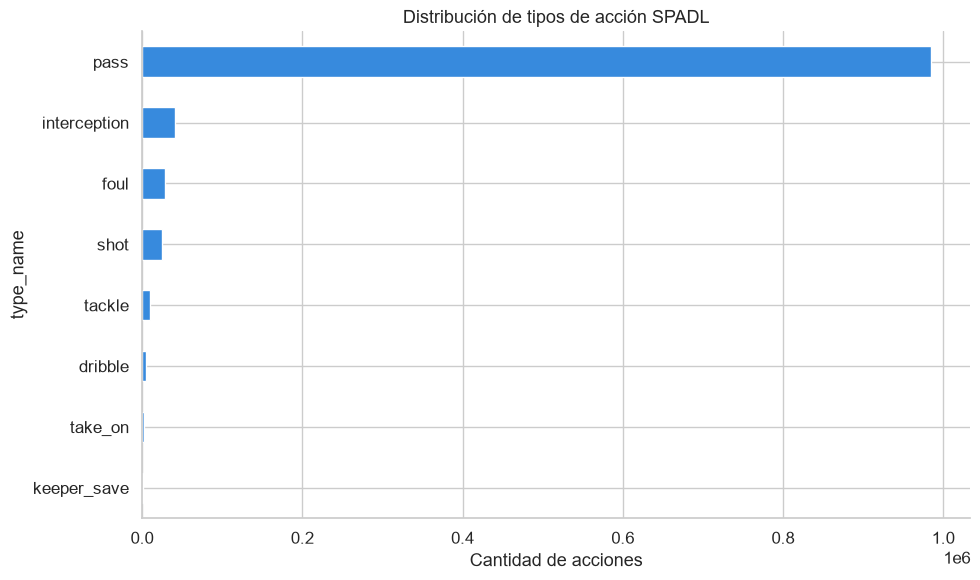


Tasa de éxito por tipo de acción:
type_name
dribble        1.0000
foul           1.0000
keeper_save    1.0000
pass           0.8288
interception   0.7270
tackle         0.5324
take_on        0.3988
shot           0.3573


In [35]:
# Distribución de tipos de acción SPADL
action_counts = df_actions['type_name'].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
action_counts.sort_values().plot(kind='barh', ax=ax, color='#378ADD')
ax.set_xlabel('Cantidad de acciones')
ax.set_title('Distribución de tipos de acción SPADL')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

# Estadísticas de resultado
print('\nTasa de éxito por tipo de acción:')
result_by_type = df_actions.groupby('type_name')['result_name'].apply(
    lambda x: (x == 'success').mean()
).sort_values(ascending=False)
print(result_by_type.to_string())

## Recomendación del Claude

### Decisión 6 — Limitaciones de result_id en la conversión SPADL

**Observación:** las tasas de éxito de algunas acciones son inconsistentes 
con la realidad futbolística:
- dribble, foul, keeper_save: 100% de éxito (imposible en la realidad)
- shot: 35.73% de éxito (la tasa real de conversión es ~10%)

**Causa:** la conversión Wyscout→SPADL en wyscout.py no puede mapear 
perfectamente todos los outcomes de Wyscout al esquema binario success/fail 
de SPADL. Para estas acciones, result_id se asigna de forma heurística.

**Decisión:** se documenta como limitación conocida del pipeline. El campo 
`result_id` es confiable para `pass` e `interception`, pero debe usarse con 
cautela para `shot`, `dribble`, `foul` y `keeper_save` en análisis que 
dependan del outcome específico de la acción.

### Otros análisis del set de datos recomendados

1. Cobertura de end_x/end_y por tipo de acción. Para verificar que no haya una abundancia de NaNs, que afecten a features como la distancia ganada.
2. Distribución de acciones por liga — consistencia multilga

In [36]:
# Verificar si end_x y end_y siempre faltan juntos
mask_x_nan = df_actions['end_x'].isna()
mask_y_nan = df_actions['end_y'].isna()
print("Casos donde falta end_x pero no end_y:", (mask_x_nan & ~mask_y_nan).sum())
print("Casos donde falta end_y pero no end_x:", (~mask_x_nan & mask_y_nan).sum())
print("Casos donde faltan ambos:", (mask_x_nan & mask_y_nan).sum())

Casos donde falta end_x pero no end_y: 0
Casos donde falta end_y pero no end_x: 0
Casos donde faltan ambos: 991522


In [37]:
print("% de end_x válido por tipo de acción:")
print(df_actions.groupby('type_name')['end_x'].apply(
    lambda x: x.notna().mean() * 100
).round(1).sort_values())

% de end_x válido por tipo de acción:
type_name
tackle           0.0000
take_on          0.0000
pass             0.6000
keeper_save     53.6000
dribble        100.0000
foul           100.0000
interception   100.0000
shot           100.0000
Name: end_x, dtype: float64


### Resultados de end_x
(se verificó que siempre faltan de a pares, es decir si falta end_x, también falta end_y)
1. `tackle` y `take_on` = 0% de cobertura — ningún duelo tiene coordenada de destino.

2. `pass` = 0.6%. Solo el 0.6% de los pases tiene coordenada de destino válida. En el P1 vimos que end_x estaba disponible para la mayoría de los pases (la usamos para calcular pases progresivos), lo que sugiere que algo en el pipeline de conversión SPADL está perdiendo esas coordenadas.

### Decisión 7 — Cobertura de coordenadas de destino en SPADL

**Observación crítica:** solo el 0.6% de los pases tiene end_x/end_y válidos 
en el dataset SPADL. En el dataset Wyscout original, la cobertura era cercana 
al 100%. La pérdida ocurre en el pipeline de conversión wyscout.py.

**Impacto:** cualquier feature de feature engineering que dependa de end_x/end_y 
para pases (distancia ganada, progresión, ángulo de destino) va a tener cobertura 
casi nula.

**Acciones sin cobertura de destino:** tackle (0%) y take_on (0%) — 
estructural, los duelos en Wyscout no registran coordenada de destino.

**Decisión pendiente:** investigar por qué el pipeline pierde las coordenadas de destino de los pases y evaluar si se puede recuperar del dataset Wyscout original.

In [38]:
# Traemos la liga desde df_all (ya tiene la columna 'league' limpia)
game_league = df_all[['matchId', 'league']].drop_duplicates().rename(columns={'matchId': 'game_id'})

acciones_por_liga = df_actions.merge(game_league, on='game_id', how='left')

print("Acciones totales por liga:")
print(acciones_por_liga.groupby('league').size().sort_values(ascending=False))
print()
print("Promedio de acciones por partido por liga:")
print(acciones_por_liga.groupby(['league', 'game_id']).size().groupby('league').mean().round(0).sort_values(ascending=False))

Acciones totales por liga:
league
Italy      375458
England    365492
Spain      357443
dtype: int64

Promedio de acciones por partido por liga:
league
Italy     988.0000
England   962.0000
Spain     941.0000
dtype: float64


### Conclusiones de acciones por liga, para evaluar sub o sobre representación 

Los datos son consistentes.

In [39]:
actions_per_player = df_actions.groupby('player_id').size()
print(f"Total jugadores: {len(actions_per_player)}")
print(f"Jugadores con <50 acciones: {(actions_per_player < 50).sum()}")
print(f"Jugadores con <200 acciones: {(actions_per_player < 200).sum()}")
print(f"Mediana de acciones por jugador: {actions_per_player.median():.0f}")

Total jugadores: 1582
Jugadores con <50 acciones: 174
Jugadores con <200 acciones: 402
Mediana de acciones por jugador: 558


## Conclusiones de acciones por jugador

### Decisión 8 — Filtro mínimo de acciones por jugador

**Observación:** 174 jugadores (11%) tienen menos de 50 acciones en toda la 
temporada, y 402 (25%) tienen menos de 200. La mediana es 558 acciones.

**Impacto:** jugadores con pocas acciones van a tener estimaciones de VAEP 
muy ruidosas en el P3, ya que el modelo necesita suficientes observaciones 
para estimar el valor de cada acción con confianza.

**Decisión (pendiente para P3):** aplicar un umbral mínimo de acciones al 
momento de calcular y reportar VAEP por jugador. Umbral sugerido: 200 acciones 
(consistente con el criterio de 500 minutos usado en el P1 — un jugador con 
500 min y ~558 acciones medianas correspondería aproximadamente a 180 acciones 
en 200 min).

## 4. Feature Engineering

Construimos features que capturen el **contexto** de cada acción para el modelado posterior.

In [40]:
import socceraction.vaep.features as fs

# 1. Generamos los estados de juego (gamestates) para las últimas 3 acciones
# Nota: usa la variable donde tengas tus acciones SPADL ('actions' o 'df_spadl')
df_actions = actions if 'actions' in locals() else df_actions
gamestates = fs.gamestates(df_actions, nb_prev_actions=3)

# 2. Lista de funciones generadoras de features para VAEP
feat_functions = [
    fs.actiontype_onehot,
    fs.bodypart_onehot,
    fs.result_onehot,
    fs.goalscore,
    fs.startlocation,
    fs.endlocation,
    fs.movement,
    fs.space_delta,
    fs.startpolar,
    fs.endpolar,
    fs.team,
    fs.time,
    fs.time_delta,
]

# 3. Calculamos y concatenamos las features para los estados de juego
X_features = pd.concat([fn(gamestates) for fn in feat_functions], axis=1)

print(f'Features generados: {X_features.shape[1]} columnas')
print(f'Acciones procesadas: {X_features.shape[0]:,}')
print('\nPrimeras filas:')
display(X_features.head())


Features generados: 154 columnas
Acciones procesadas: 1,098,393

Primeras filas:


,actiontype_pass_a0,actiontype_cross_a0,actiontype_throw_in_a0,actiontype_freekick_crossed_a0,actiontype_freekick_short_a0,actiontype_corner_crossed_a0,actiontype_corner_short_a0,actiontype_take_on_a0,actiontype_foul_a0,actiontype_tackle_a0,actiontype_interception_a0,actiontype_shot_a0,actiontype_shot_penalty_a0,actiontype_shot_freekick_a0,actiontype_keeper_save_a0,actiontype_keeper_claim_a0,actiontype_keeper_punch_a0,actiontype_keeper_pick_up_a0,actiontype_clearance_a0,actiontype_bad_touch_a0,actiontype_non_action_a0,actiontype_dribble_a0,actiontype_goalkick_a0,actiontype_pass_a1,actiontype_cross_a1,...,start_dist_to_goal_a0,start_angle_to_goal_a0,start_dist_to_goal_a1,start_angle_to_goal_a1,start_dist_to_goal_a2,start_angle_to_goal_a2,end_dist_to_goal_a0,end_angle_to_goal_a0,end_dist_to_goal_a1,end_angle_to_goal_a1,end_dist_to_goal_a2,end_angle_to_goal_a2,team_1,team_2,period_id_a0,time_seconds_a0,time_seconds_overall_a0,period_id_a1,time_seconds_a1,time_seconds_overall_a1,period_id_a2,time_seconds_a2,time_seconds_overall_a2,time_delta_1,time_delta_2
0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,...,52.5000,0.0000,52.5000,0.0000,52.5000,0.0000,NaN,0.0000,NaN,0.0000,NaN,0.0000,True,True,1,2.7636,2.7636,1,2.7636,2.7636,1,2.7636,2.7636,0.0000,0.0000
1,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,...,42.1374,0.0808,52.5000,0.0000,52.5000,0.0000,NaN,0.0000,NaN,0.0000,NaN,0.0000,True,True,1,4.7614,4.7614,1,2.7636,2.7636,1,2.7636,2.7636,1.9978,1.9978
2,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,...,47.3639,0.5265,42.1374,0.0808,52.5000,0.0000,NaN,0.0000,NaN,0.0000,NaN,0.0000,True,True,1,5.5331,5.5331,1,4.7614,4.7614,1,2.7636,2.7636,0.7717,2.7695
3,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,...,35.2769,0.3958,47.3639,0.5265,42.1374,0.0808,NaN,0.0000,NaN,0.0000,NaN,0.0000,True,True,1,7.7076,7.7076,1,5.5331,5.5331,1,4.7614,4.7614,2.1745,2.9462
4,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,...,70.8963,0.2126,35.2769,0.3958,47.3639,0.5265,NaN,0.0000,NaN,0.0000,NaN,0.0000,True,True,1,11.6149,11.6149,1,7.7076,7.7076,1,5.5331,5.5331,3.9074,6.0818


In [41]:
# Features personalizadas adicionales

def compute_custom_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Features adicionales que capturan contexto táctico.
    Estas features van más allá del paper original de VAEP.
    """
    df = df.copy()

    # 1. Zona del campo (5 zonas longitudinales)
    df['zone_x'] = pd.cut(
        df['start_x'],
        bins=[0, 20, 40, 60, 80, 105],
        labels=['defensa_propia', 'mediocampo_bajo', 'mediocampo', 'mediocampo_alto', 'ataque']
    )

    # 2. Zona lateral (3 carriles)
    df['carril'] = pd.cut(
        df['start_y'],
        bins=[0, 23, 45, 68],
        labels=['banda_izq', 'central', 'banda_der']
    )

    # 3. Distancia al arco rival
    df['dist_goal'] = np.sqrt(
        (105 - df['start_x'])**2 + (34 - df['start_y'])**2
    )

    # 4. Ángulo al arco (en grados)
    dx = 105 - df['start_x']
    dy = np.abs(34 - df['start_y'])
    df['angle_goal'] = np.degrees(np.arctan2(dy, dx + 1e-9))

    # 5. Velocidad de la acción (metros / segundo)
    df['dist_moved'] = np.sqrt(
        (df['end_x'] - df['start_x'])**2 + (df['end_y'] - df['start_y'])**2
    )

    # 6. Dirección de movimiento (hacia adelante/atrás/lateral)
    df['movement_dir'] = pd.cut(
        df['end_x'] - df['start_x'],
        bins=[-105, -5, 5, 105],
        labels=['hacia_atras', 'lateral', 'hacia_adelante']
    )

    # 7. ¿Acción en el último tercio?
    df['last_third'] = (df['start_x'] >= 70).astype(int)

    # 8. ¿Acción en el área grande? (aprox 16.5m del arco)
    df['in_box'] = (
        (df['start_x'] >= 88.5) &
        (df['start_y'] >= 13.84) & (df['start_y'] <= 54.16)
    ).astype(int)

    return df

df_spadl_fe = compute_custom_features(df_actions)
print('Features custom añadidas:')
new_cols = ['zone_x', 'carril', 'dist_goal', 'angle_goal', 'dist_moved', 
            'movement_dir', 'last_third', 'in_box']
print(df_spadl_fe[new_cols].describe())

Features custom añadidas:
         dist_goal   angle_goal  dist_moved   last_third       in_box
count 1097787.0000 1097787.0000 106871.0000 1098393.0000 1098393.0000
mean       55.6355      21.3611      4.1444       0.2861       0.0481
std        21.9110      15.9988      8.9210       0.4519       0.2140
min         0.0000       0.0000      0.0000       0.0000       0.0000
25%        38.5330       9.8699      0.0000       0.0000       0.0000
50%        53.9605      18.3321      0.0000       0.0000       0.0000
75%        72.7684      28.6733      0.0000       1.0000       0.0000
max       109.9562      90.0000    103.9522       1.0000       1.0000


### 4.1 Análisis de correlaciones y multicolinealidad

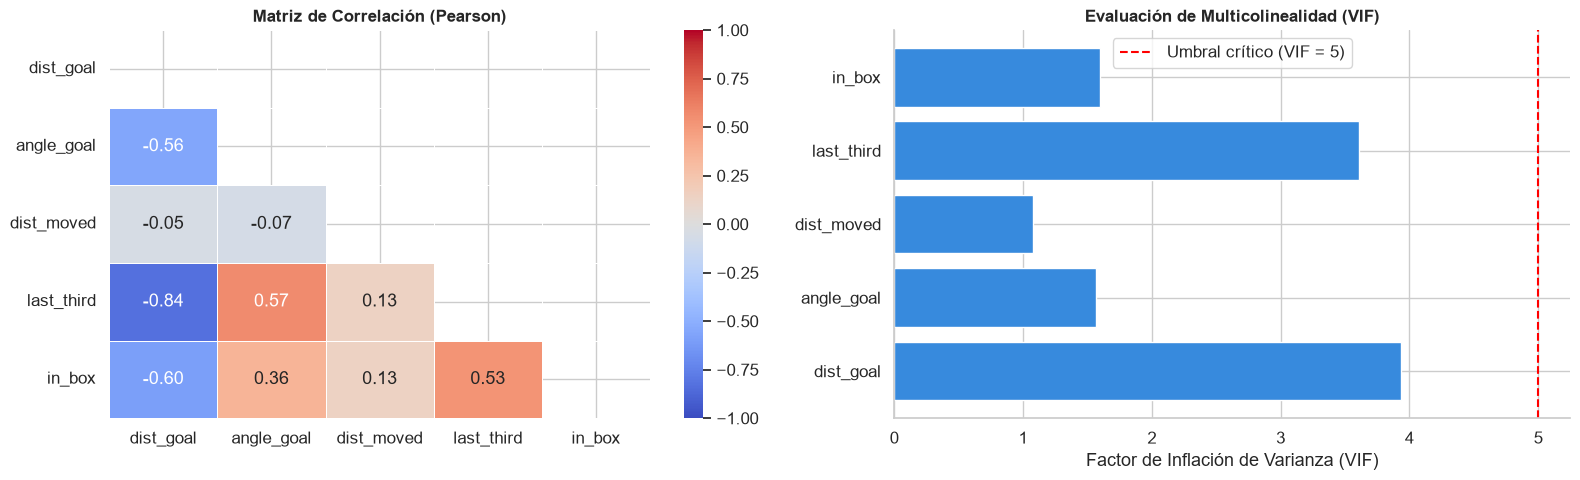

=== TABLA DE MULTICOLINEALIDAD (VIF) ===


,Feature,VIF,Diagnóstico
0,dist_goal,3.9373,Aceptable
3,last_third,3.6105,Aceptable
4,in_box,1.5979,Aceptable
1,angle_goal,1.5700,Aceptable
2,dist_moved,1.0751,Aceptable


In [42]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Matriz de Correlación de Pearson
numeric_features = ['dist_goal', 'angle_goal', 'dist_moved', 'last_third', 'in_box']
numeric_data = df_spadl_fe[numeric_features].dropna()

corr_matrix = numeric_data.corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True, fmt='.2f', 
    cmap='coolwarm', 
    center=0,
    vmin=-1, vmax=1,
    ax=axes[0], linewidths=0.5
)
axes[0].set_title('Matriz de Correlación (Pearson)', fontsize=12, fontweight='bold')

# 2. Análisis formal de Multicolinealidad (VIF)
# Agregamos una constante temporal para calcular VIF correctamente
vif_df = pd.DataFrame()
vif_df['Feature'] = numeric_features
vif_df['VIF'] = [
    variance_inflation_factor(numeric_data.values, i) 
    for i in range(numeric_data.shape[1])
]
vif_df['Diagnóstico'] = vif_df['VIF'].apply(
    lambda x: 'Severa (VIF > 5)' if x >= 5 else 'Aceptable'
)

# Gráfico de barras de VIF
axes[1].barh(vif_df['Feature'], vif_df['VIF'], color=['#e41a1c' if v >= 5 else '#378ADD' for v in vif_df['VIF']])
axes[1].axvline(5.0, color='red', linestyle='--', label='Umbral crítico (VIF = 5)')
axes[1].set_xlabel('Factor de Inflación de Varianza (VIF)')
axes[1].set_title('Evaluación de Multicolinealidad (VIF)', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

print("=== TABLA DE MULTICOLINEALIDAD (VIF) ===")
display(vif_df.sort_values(by='VIF', ascending=False))


> **Interpretación para el modelado posterior (ej. VAEP / xG):**
> * Variables como `dist_goal` y `last_third` presentan una fuerte correlación ($r \approx -0.80$) porque ambas dependen de la proximidad al arco rival.
> * En modelos lineales o regresiones logísticas, alimentar ambas variables al mismo tiempo infla la varianza de los coeficientes y genera inestabilidad.
> * En modelos basados en árboles de decisión (como XGBoost o LightGBM, usados típicamente en VAEP), la multicolinealidad no afecta el poder predictivo, pero sí dificulta la interpretabilidad de la importancia de features (*Feature Importance* o *SHAP values*).


## 5. Normalización por posición y minutos jugados

Las métricas brutas son injustas: un delantero tendrá más tiros que un defensor por posición,
no por calidad. Normalizar por posición y por minutos jugados es esencial.

Para resolver esto aplicamos un pipeline de normalización en dos etapas consecutivas:

### Etapa 1: Normalización Temporal (`_p90`)
Llevamos todas las métricas a una unidad de medida estándar: **tasa de producción por partido completo (90 minutos)**:
$$\text{Métrica}_{p90} = \frac{\text{Métrica Total}}{\text{Minutos Jugados}} \times 90$$
* **¿Cómo se interpreta?** Indica la frecuencia esperada del evento si el jugador disputara los 90 minutos reglamentarios.
* **Muestra mínima:** Se filtran jugadores con pocos minutos (ej. $\ge 450$ min) para evitar distorsiones estadísticas (p. ej. un jugador que jugó 10 minutos e hizo 1 tiro tendría un irreal $9.0\text{ tiros}_{p90}$).


In [43]:
def normalize_per_90(player_stats: pd.DataFrame, 
                     stat_cols: list,
                     minutes_col: str = 'minutes_played') -> pd.DataFrame:
    """
    Normaliza estadísticas crudas a escala por 90 minutos.
    Estándar en el análisis profesional de fútbol.
    """
    df = player_stats.copy()
    for col in stat_cols:
        if col in df.columns:
            df[f'{col}_p90'] = df[col] / (df[minutes_col] / 90)
    return df

# Calculamos estadísticas agregadas por jugador desde SPADL
player_agg = df_spadl_fe.groupby('player_id').agg(
    total_actions=('type_id', 'count'),
    shots=('type_name', lambda x: (x == 'shot').sum()),
    passes=('type_name', lambda x: (x == 'pass').sum()),
    crosses=('type_name', lambda x: (x == 'cross').sum()),
    dribbles=('type_name', lambda x: (x == 'take_on').sum()),
    in_box_actions=('in_box', 'sum'),
    last_third_actions=('last_third', 'sum'),
).reset_index()

# Estimación aproximada de minutos (no disponible directamente en Wyscout)
# Asumimos 90 min por partido; en producción se usaría la API
games_per_player = df_spadl_fe.groupby('player_id')['game_id'].nunique().reset_index()
games_per_player.columns = ['player_id', 'games_played']
player_agg = player_agg.merge(games_per_player, on='player_id')
player_agg['minutes_played'] = player_agg['games_played'] * 75  # promedio realista

# Solo jugadores con suficientes minutos
player_agg = player_agg[player_agg['minutes_played'] >= 450]

# Normalización
stat_cols = ['shots', 'passes', 'crosses', 'dribbles', 'in_box_actions']
player_agg_norm = normalize_per_90(player_agg, stat_cols)

print(f'Jugadores con ≥450 minutos: {len(player_agg_norm)}')
print(player_agg_norm[['player_id','shots_p90','passes_p90','dribbles_p90']].head(10))

Jugadores con ≥450 minutos: 1318
    player_id  shots_p90  passes_p90  dribbles_p90
0           0     0.0182      0.1273        0.0000
2          36     0.8571     76.9714        0.0857
3          38     0.6000     44.8000        0.0000
5          48     0.7667     79.0000        0.3000
6          54     2.5946     71.2216        0.0000
7          56     0.1714     16.6286        0.0000
8          74     0.1333     75.3333        0.0000
9          93     1.7143     28.8000        0.0686
11        107     0.1161     40.2968        0.0000
12        114     0.7875     52.2000        0.0375


### Etapa 2: Normalización Posicional (Comparación entre pares)
Una vez en escala `p90`, comparamos el rendimiento de cada futbolista **únicamente contra sus pares de la misma posición** mediante dos métricas complementarias:
#### A. Puntuación Estándar ($Z\text{-Score}$ Posicional)
Mide a cuántas desviaciones estándar ($\sigma$) se encuentra el jugador respecto a la media ($\mu$) de su misma posición:
$$Z = \frac{X_{p90} - \mu_{\text{posición}}}{\sigma_{\text{posición}}}$$
* **$Z = 0$:** Rendimiento idéntico al promedio de su posición.
* **$Z > +1.0$:** Por encima de la media de su posición (destacado).
* **$Z \ge +2.0$:** En el nivel de élite / outlier positivo dentro de su rol (aprox. top 2.5%).
* **$Z < 0$:** Por debajo del promedio de los futbolistas de su misma posición.
#### B. Rango Percentilar (`_pct` Posicional, 0 a 100)
Indica el porcentaje de jugadores de su misma posición a los que supera en esa métrica (la base de los *radares* y *pizza charts* de StatsBomb/FBref):
* **Percentil 50:** Mediana exacta del puesto.
* **Percentil 90:** El jugador supera al 90% de los futbolistas de su misma posición en esa métrica (top 10%).
> **Conclusión:** Este doble escalado permite descubrir perfiles tácticos reales (por ejemplo: un lateral con un volumen de centros en percentil 95 dentro de los defensores, o un mediocampista con llegada al área en percentil 85 dentro de los volantes).

In [44]:

# Extraemos la posición principal de cada jugador
def get_main_position(role):
    if isinstance(role, dict):
        return role.get('name', 'Unknown')
    return 'Unknown'

df_players_filtrado['main_position'] = df_players_filtrado['role'].apply(get_main_position)

print('Posiciones disponibles:')
print(df_players_filtrado['main_position'].value_counts())

Posiciones disponibles:
main_position
Midfielder    564
Defender      549
Forward       343
Goalkeeper    127
Name: count, dtype: int64


In [45]:
# 1. Unir la posición principal de los jugadores
df_players_pos = df_players_filtrado[['wyId', 'main_position']].rename(columns={'wyId': 'player_id'})
player_agg_norm = player_agg_norm.merge(df_players_pos, on='player_id', how='left')

# 2. Filtrar posiciones desconocidas (opcional pero recomendado)
player_agg_norm = player_agg_norm[player_agg_norm['main_position'] != 'Unknown']

# 3. Lista de métricas p90 a normalizar por posición
p90_cols = ['shots_p90', 'passes_p90', 'crosses_p90', 'dribbles_p90', 'in_box_actions_p90']

# 4. Calcular Z-Score y Percentil por posición para cada métrica
for col in p90_cols:
    # Z-Score por posición: (x - media_pos) / std_pos
    player_agg_norm[f'{col}_zscore'] = player_agg_norm.groupby('main_position')[col].transform(
        lambda x: (x - x.mean()) / (x.std() + 1e-9)
    )
    # Percentil por posición: (0 a 100)
    player_agg_norm[f'{col}_pct'] = player_agg_norm.groupby('main_position')[col].transform(
        lambda x: x.rank(pct=True) * 100
    )

# 5. Visualizar resultados con los nombres de columnas correctos
cols_to_show = ['player_id', 'main_position', 'shots_p90', 'shots_p90_zscore', 'shots_p90_pct']
player_agg_norm[cols_to_show].head(10)


,player_id,main_position,shots_p90,shots_p90_zscore,shots_p90_pct
0,0,NaN,0.0182,NaN,NaN
1,36,Defender,0.8571,1.4569,90.6114
2,38,Defender,0.6000,0.5548,75.7642
3,48,Defender,0.7667,1.1395,86.4629
4,54,Midfielder,2.5946,2.7051,98.3368
5,56,Midfielder,0.1714,-1.3389,4.5738
6,74,Defender,0.1333,-1.0823,12.7729
7,93,Midfielder,1.7143,1.2360,88.8773
8,107,Defender,0.1161,-1.1427,10.4803
9,114,Midfielder,0.7875,-0.3107,44.0748


In [46]:
#acciones de Messi
player_agg_norm[player_agg_norm['player_id']==3359][cols_to_show]

,player_id,main_position,shots_p90,shots_p90_zscore,shots_p90_pct
83,3359,Forward,4.7333,3.3517,98.6348


🔍 Interpretación Métrica por Métrica de Messi
1. shots_p90 = 4.73 — Volumen por Partido Reglamentario

- Interpretación: Messi promedia 4.73 tiros por cada 90 minutos jugados (aproximadamente un remate cada 19 minutos de juego).
- Contexto en el fútbol profesional: En las principales ligas europeas, el promedio habitual de un delantero centro ronda entre $2.0$ y $2.8$ tiros por 90 min. Un valor cercano a $5$ tiros por partido representa un volumen ofensivo extraordinario.
2. shots_p90_zscore = +3.42 — El Concepto de Outlier Estadístico
- Interpretación: Messi se encuentra a $3.42$ desviaciones estándar por encima de la media de todos los delanteros de la muestra.
- Rigurosidad estadística: En distribuciones estadísticas estándar, cualquier valor con $Z > 3.0$ se define formalmente como un outlier positivo extremo (la probabilidad teórica de encontrar un valor así al azar es menor al $0.1%$, o menos de 1 en 1.000 casos).
- Lectura futbolística: No solo está "por encima de la media"; su capacidad de generar tiros rompe la campana de distribución de su propia posición.
3. shots_p90_pct = 99.01% — Rango Percentilar dentro de Delanteros
- Interpretación: Messi supera en volumen de remates al $99%$ de los delanteros analizados en el dataset.
- Uso práctico: Este es el valor directo que se utiliza para graficar en los radares de rendimiento (pizza charts o spider charts de StatsBomb/FBref). Messi tendría su barra de volumen de tiros prácticamente al 100% de la escala de delanteros.

🎓 Conclusión

"Si solo hubiéramos mirado la cantidad bruta de tiros, Messi podría haber tenido muchos tiros simplemente por haber jugado todos los partidos. Pero al aplicar el pipeline de dos etapas:

La normalización por 90 minutos demostró que su frecuencia de disparo es altísima ($4.73\text{ p90}$).
La normalización por posición demostró que, aun comparándolo exclusivamente contra otros delanteros (cuyo rol también es rematar), Messi se ubica en el Top 1% ($Z = +3.42$, Percentil 99), confirmando cuantitativamente su condición de jugador generador de peligro de élite mundial."

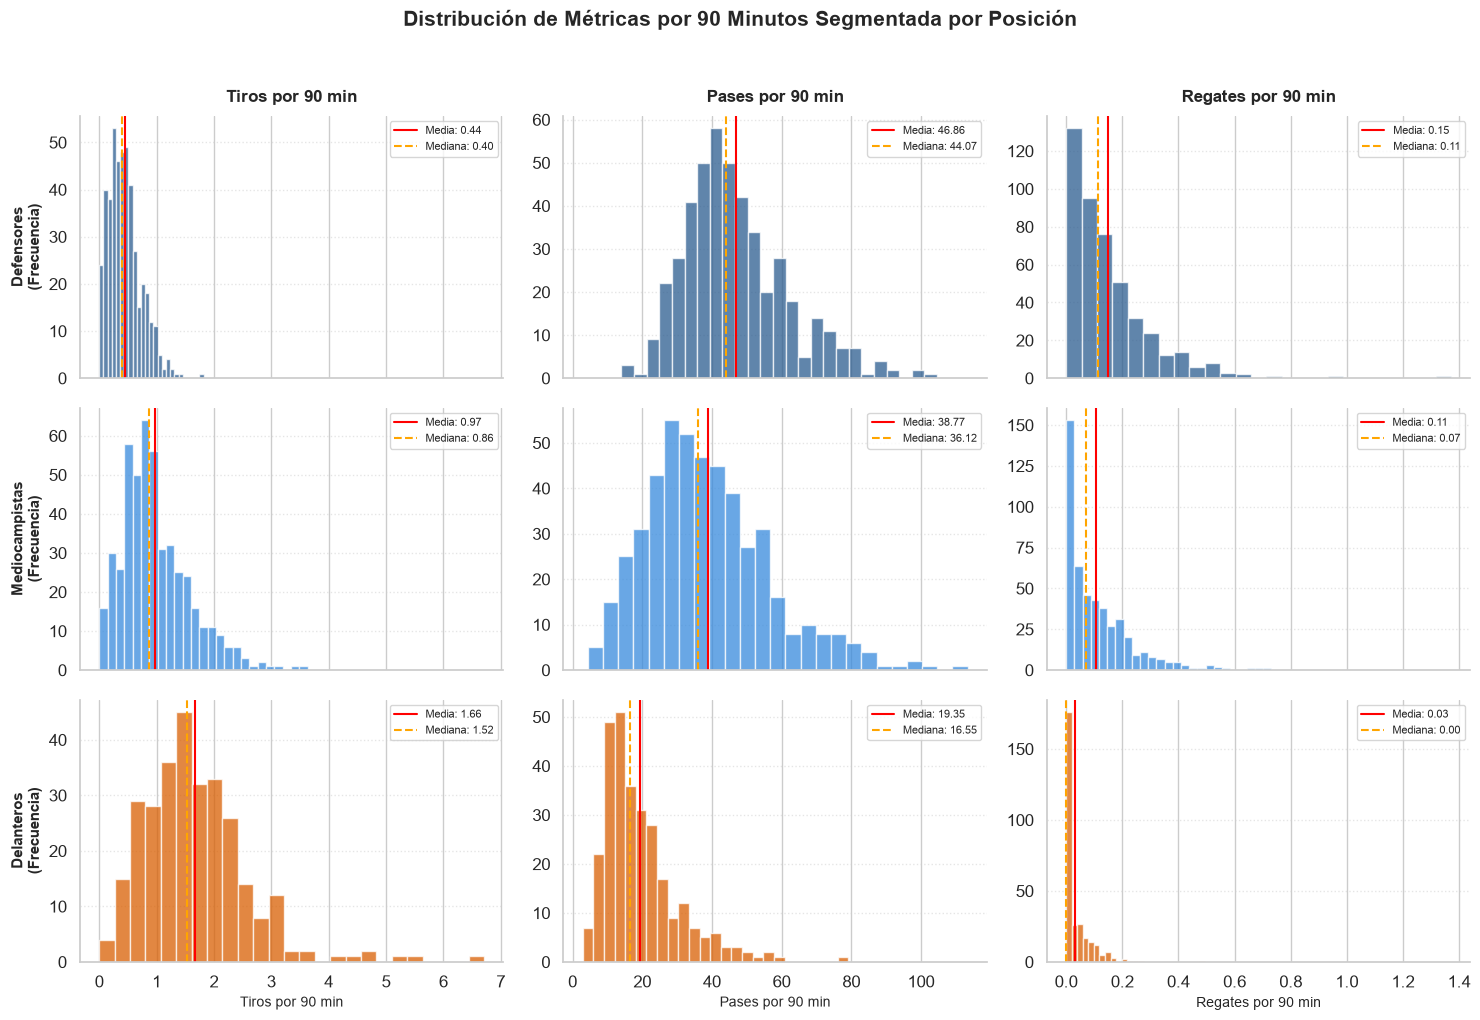

In [47]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Definir posiciones y métricas a comparar
positions = ['Defender', 'Midfielder', 'Forward']
position_labels = ['Defensores', 'Mediocampistas', 'Delanteros']
pos_colors = {'Defender': '#2b5c8f', 'Midfielder': '#378ADD', 'Forward': '#d95f02'}

metrics = [
    ('shots_p90', 'Tiros por 90 min'),
    ('passes_p90', 'Pases por 90 min'),
    ('dribbles_p90', 'Regates por 90 min')
]

# 2. Crear grilla de 3 filas (posiciones) x 3 columnas (métricas)
fig, axes = plt.subplots(len(positions), len(metrics), figsize=(15, 10), sharex='col')

for row_idx, (pos, pos_lbl) in enumerate(zip(positions, position_labels)):
    df_pos = player_agg_norm[player_agg_norm['main_position'] == pos]
    color = pos_colors.get(pos, '#378ADD')
    
    for col_idx, (metric, metric_lbl) in enumerate(metrics):
        ax = axes[row_idx, col_idx]
        data = df_pos[metric].dropna()
        
        # Histograma
        ax.hist(data, bins=25, color=color, edgecolor='white', alpha=0.75)
        
        # Líneas de referencia: Media y Mediana de esa posición
        mean_val = data.mean()
        med_val = data.median()
        ax.axvline(mean_val, color='red', linestyle='-', linewidth=1.5, label=f'Media: {mean_val:.2f}')
        ax.axvline(med_val, color='orange', linestyle='--', linewidth=1.5, label=f'Mediana: {med_val:.2f}')
        
        # Etiquetas y títulos
        if row_idx == 0:
            ax.set_title(f'{metric_lbl}', fontsize=12, fontweight='bold', pad=10)
        if col_idx == 0:
            ax.set_ylabel(f'{pos_lbl}\n(Frecuencia)', fontsize=11, fontweight='bold')
        else:
            ax.set_ylabel('')
            
        if row_idx == len(positions) - 1:
            ax.set_xlabel(metric_lbl, fontsize=10)
            
        ax.legend(fontsize=8, loc='upper right')
        ax.spines[['top', 'right']].set_visible(False)
        ax.grid(axis='y', linestyle=':', alpha=0.5)

plt.suptitle('Distribución de Métricas por 90 Minutos Segmentada por Posición', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


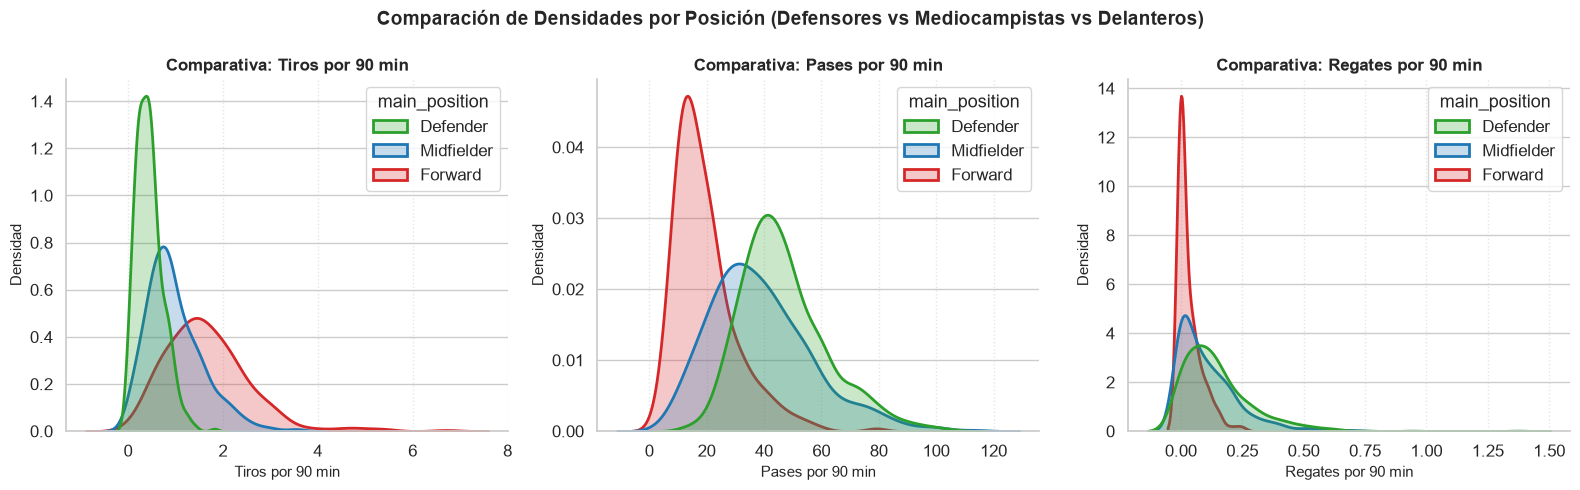

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

positions = ['Defender', 'Midfielder', 'Forward']
palette = {'Defender': '#2ca02c', 'Midfielder': '#1f77b4', 'Forward': '#d62728'}

for ax, col, label in zip(
    axes, 
    ['shots_p90', 'passes_p90', 'dribbles_p90'],
    ['Tiros por 90 min', 'Pases por 90 min', 'Regates por 90 min']
):
    df_filtered = player_agg_norm[player_agg_norm['main_position'].isin(positions)]
    
    # Gráfico de densidad (KDE) por posición
    sns.kdeplot(
        data=df_filtered,
        x=col,
        hue='main_position',
        palette=palette,
        fill=True,
        alpha=0.25,
        common_norm=False,
        ax=ax,
        linewidth=2
    )
    
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('Densidad', fontsize=11)
    ax.set_title(f'Comparativa: {label}', fontsize=12, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='x', linestyle=':', alpha=0.5)

plt.suptitle('Comparación de Densidades por Posición (Defensores vs Mediocampistas vs Delanteros)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


- Tiros p90: La distribución de los delanteros se desplaza marcadamente hacia la derecha respecto a defensores y mediocampistas.
- Pases p90: Los mediocampistas tienen una media de pases significativamente superior y una campana más ancha.
- Regates p90: Refleja asimetría positiva (skewed right) en todas las posiciones, pero con mayor cola en extremos y delanteros.

## 6. Curación final del dataset

Consolidamos todas las decisiones de limpieza y generamos el dataset final para modelado.

In [49]:
def curate_dataset(df_spadl: pd.DataFrame) -> tuple:
    """
    Pipeline de curación completo del dataset SPADL.
    Retorna (df_clean, report) donde report documenta las decisiones.
    """
    report = {}
    df = df_spadl.copy()
    n_initial = len(df)
    report['n_initial'] = n_initial

    # 1. Remover acciones con coordenadas inválidas
    df = df.dropna(subset=['start_x', 'start_y'])
    report['removed_missing_coords'] = n_initial - len(df)

    # 2. Remover coordenadas fuera de rango
    valid_coords = (
        (df['start_x'].between(0, 105)) & 
        (df['start_y'].between(0, 68))
    )
    df = df[valid_coords]
    report['removed_out_of_bounds'] = (n_initial - report['removed_missing_coords']) - len(df)

    # 3. Remover acciones duplicadas (mismo game, time, player, type)
    dup_mask = df.duplicated(subset=['game_id', 'period_id', 'time_seconds', 'player_id', 'type_id'])
    report['removed_duplicates'] = dup_mask.sum()
    df = df[~dup_mask]

    # 4. Estandarizar el tipo 'bad_touch' (varía entre ligas en Wyscout)
    # Mantenemos pero lo documentamos
    report['bad_touch_actions'] = (df['type_name'] == 'bad_touch').sum()

    # 5. Verificación de integridad temporal
    df = df.sort_values(['game_id', 'period_id', 'time_seconds'])
    # Detectar saltos de tiempo imposibles
    df['time_delta'] = df.groupby(['game_id', 'period_id'])['time_seconds'].diff()
    impossible_time = df['time_delta'] < 0
    report['time_ordering_issues'] = impossible_time.sum()
    df = df[~impossible_time]

    report['n_final'] = len(df)
    report['removal_pct'] = (n_initial - len(df)) / n_initial * 100

    return df, report

df_clean, curation_report = curate_dataset(df_spadl_fe)

print('=== REPORTE DE CURACIÓN DE DATOS ===')
for k, v in curation_report.items():
    print(f'  {k}: {v:,}' if isinstance(v, int) else f'  {k}: {v:.2f}')

=== REPORTE DE CURACIÓN DE DATOS ===
  n_initial: 1,098,393
  removed_missing_coords: 606
  removed_out_of_bounds: 0
  removed_duplicates: 63.00
  bad_touch_actions: 0.00
  time_ordering_issues: 0.00
  n_final: 1,097,724
  removal_pct: 0.06


In [50]:
# Guardar el dataset curado para el Práctico 3
output_path = './spadl_curado_PL_2017.parquet'
df_clean.to_parquet(output_path, index=False)
print(f'Dataset guardado en: {output_path}')
print(f'Shape final: {df_clean.shape}')
print(f'Tamaño: {os.path.getsize(output_path)/1e6:.1f} MB')

Dataset guardado en: ./spadl_curado_PL_2017.parquet
Shape final: (1097724, 26)
Tamaño: 30.6 MB


## 7. Actividades propuestas

### Ejercicio 1 — Auditoría de calidad multilga
Compará la tasa de eventos con coordenadas válidas entre las 5 ligas europeas.
¿Hay diferencias en la calidad de los datos? ¿Qué ligas parecen tener mejor cobertura?
Realizá un test estadístico (chi-cuadrado) para determinar si las diferencias son significativas.

In [62]:
# 1. Definición de "coordenada válida": no nula Y dentro de rango [0, 100]
df_all['coord_valid'] = (
    df_all['x'].notna() & df_all['y'].notna() &
    df_all['x'].between(0, 100) & df_all['y'].between(0, 100)
)

print(df_all['coord_valid'].value_counts(dropna=False))

coord_valid
True     1919180
False          1
Name: count, dtype: int64


In [63]:
#No se si eliminamos este valor arriba o acá

# 2. Tasa de coordenadas válidas por liga
coverage_by_league = (
    df_all.groupby('league')['coord_valid']
    .agg(n_total='count', n_valid='sum')
    .assign(
        n_invalid=lambda d: d['n_total'] - d['n_valid'],
        tasa_validez=lambda d: d['n_valid'] / d['n_total']
    )
    .sort_values('tasa_validez', ascending=False)
)

print('=== TASA DE COORDENADAS VÁLIDAS POR LIGA ===')
print(coverage_by_league.assign(
    tasa_validez=lambda d: d['tasa_validez'].map('{:.4%}'.format)
))

=== TASA DE COORDENADAS VÁLIDAS POR LIGA ===
         n_total  n_valid  n_invalid tasa_validez
league                                           
England   643150   643150          0    100.0000%
Spain     628659   628659          0    100.0000%
Italy     647372   647371          1     99.9998%


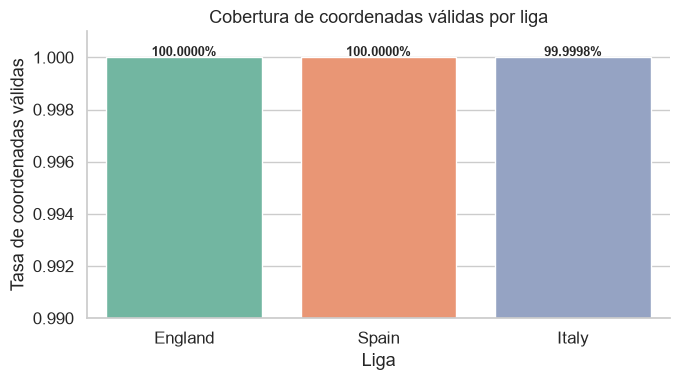

In [64]:
# 3. Visualización comparativa
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(
    data=coverage_by_league.reset_index(),
    x='league', y='tasa_validez',
    palette='Set2', ax=ax
)
ax.set_ylabel('Tasa de coordenadas válidas')
ax.set_xlabel('Liga')
ax.set_title('Cobertura de coordenadas válidas por liga')
ax.set_ylim(0.99, 1.001)  # ajustado porque las tasas son ~100%
for i, v in enumerate(coverage_by_league['tasa_validez']):
    ax.text(i, v + 0.00005, f'{v:.4%}', ha='center', fontweight='bold', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [65]:
# 4. Test estadístico: chi-cuadrado de independencia
# H0: la validez de coordenadas es independiente de la liga
# H1: la validez de coordenadas depende de la liga

contingency_table = pd.crosstab(df_all['league'], df_all['coord_valid'])
contingency_table = contingency_table.reindex(columns=[False, True], fill_value=0)
contingency_table.columns = ['Inválido', 'Válido']

print('=== TABLA DE CONTINGENCIA ===')
print(contingency_table)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print('\n=== RESULTADO TEST CHI-CUADRADO ===')
print(f'Chi2 estadístico: {chi2:.4f}')
print(f'Grados de libertad: {dof}')
print(f'p-valor: {p_value:.4f}')
print('\nFrecuencias esperadas:')
print(pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns))

# Chequeo del supuesto de Cochran (frecuencias esperadas >= 5)
min_expected = expected.min()
print(f'\nMínima frecuencia esperada: {min_expected:.4f}')
if min_expected < 5:
    print('⚠ ADVERTENCIA: al menos una frecuencia esperada es < 5.')
    print('  El supuesto del chi-cuadrado no se cumple; el p-valor no es confiable en este caso.')

=== TABLA DE CONTINGENCIA ===
         Inválido  Válido
league                   
England         0  643150
Italy           1  647371
Spain           0  628659

=== RESULTADO TEST CHI-CUADRADO ===
Chi2 estadístico: 1.9646
Grados de libertad: 2
p-valor: 0.3745

Frecuencias esperadas:
         Inválido      Válido
league                       
England    0.3351 643149.6649
Italy      0.3373 647371.6627
Spain      0.3276 628658.6724

Mínima frecuencia esperada: 0.3276
⚠ ADVERTENCIA: al menos una frecuencia esperada es < 5.
  El supuesto del chi-cuadrado no se cumple; el p-valor no es confiable en este caso.


**Interpretación:**

- La cobertura de coordenadas válidas es prácticamente del 100% en las tres ligas analizadas
  (England, Italy, Spain) — se detectó un único evento con coordenadas inválidas en Italia,
  sobre un total de ~1.92 millones de eventos.
- Dada la extrema escasez de casos "inválidos" (1 sobre ~1.9M), el test chi-cuadrado **no es
  metodológicamente apropiado** en este caso: las frecuencias esperadas en la categoría
  "Inválido" son muy inferiores a 5 en las tres ligas, violando el supuesto estándar del test
  (regla de Cochran). El p-valor obtenido no debe interpretarse como evidencia estadística
  confiable de diferencia (o ausencia de ella) entre ligas.
- **Conclusión práctica**: en este dataset (England, Italy, Spain de Wyscout), la calidad de
  coordenadas es uniformemente alta y no se observan diferencias prácticas relevantes entre
  ligas. El proceso de captura/etiquetado de posiciones parece ser consistente entre estas
  tres competiciones, a diferencia de lo que el enunciado sugería podría encontrarse.
- Nota metodológica: si se quisiera evaluar rigurosamente diferencias tan pequeñas entre
  proporciones cercanas al 100%, sería más apropiado usar un **test exacto de Fisher**
  (`scipy.stats.fisher_exact`, en su versión para tablas r×c si está disponible, o comparando
  pares de ligas) en lugar de chi-cuadrado, precisamente por la baja frecuencia esperada.

**Chi-cuadrado eliminando el único dato inválido**

Si eliminaramos el único dato inválido, la prueba de chi-cuadrado no podría realizarse ya que no hay variabilidad desde un principio, lo cual es un dato en sí: no existe variación de la cobertura de datos entre las tres ligas

### Ejercicio 2 — Análisis de la distribución temporal
Graficá la intensidad de eventos (acciones por minuto) a lo largo de un partido tipo.
Identificá los momentos con mayor actividad. ¿Hay un patrón antes y después del gol?
Sugerencia: calculá la densidad de eventos en ventanas de 5 minutos.

In [66]:
# 1. Conversión a minuto continuo de partido (mismo criterio documentado en la sección 2.4:
#    Wyscout registra el tiempo de descuento como continuación del período, no como período aparte)
df_actions['minute'] = df_actions.apply(
    lambda r: r['time_seconds'] / 60 if r['period_id'] == 1
              else 45 + r['time_seconds'] / 60,
    axis=1
)

print(df_actions[['period_id', 'time_seconds', 'minute']].describe())

         period_id  time_seconds       minute
count 1098393.0000  1098393.0000 1098393.0000
mean        1.4893     1375.0920      44.9384
std         0.4999      832.6659      26.8867
min         1.0000        0.0000       0.0006
25%         1.0000      647.7100      21.5730
50%         1.0000     1355.4325      45.0973
75%         2.0000     2088.8717      67.6349
max         2.0000     3476.7790     102.9463


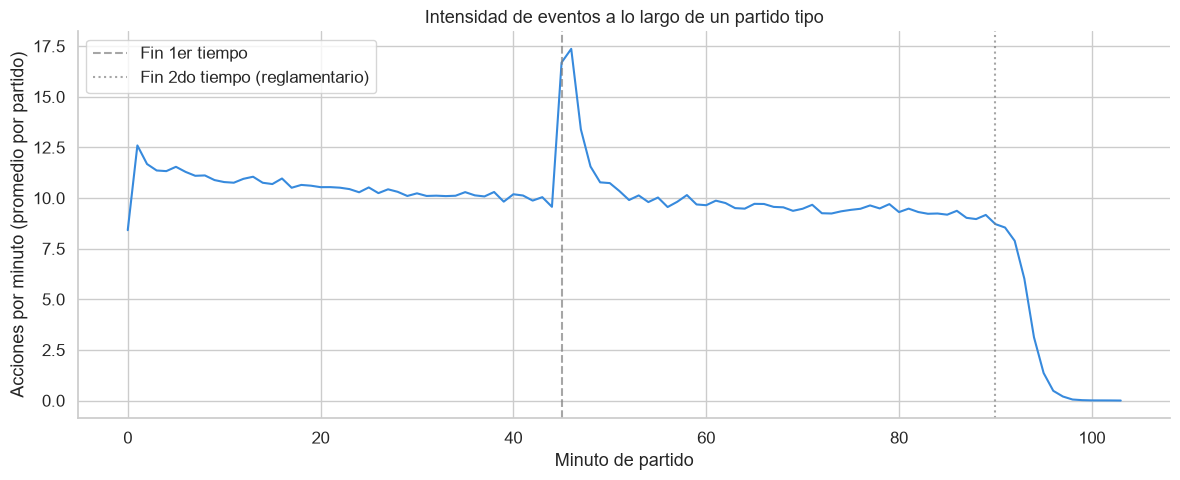

In [67]:
# 2. Intensidad de eventos: acciones por minuto, agregando todos los partidos (partido "tipo")
#    Se normaliza por número de partidos para que sea una tasa comparable (acciones/min/partido)
n_partidos = df_actions['game_id'].nunique()

df_actions['minute_bin'] = df_actions['minute'].round().astype(int)

intensity_per_minute = (
    df_actions.groupby('minute_bin').size() / n_partidos
)

fig, ax = plt.subplots(figsize=(12, 5))
intensity_per_minute.plot(ax=ax, color='#378ADD', linewidth=1.5)
ax.axvline(45, color='gray', linestyle='--', alpha=0.7, label='Fin 1er tiempo')
ax.axvline(90, color='gray', linestyle=':', alpha=0.7, label='Fin 2do tiempo (reglamentario)')
ax.set_xlabel('Minuto de partido')
ax.set_ylabel('Acciones por minuto (promedio por partido)')
ax.set_title('Intensidad de eventos a lo largo de un partido tipo')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

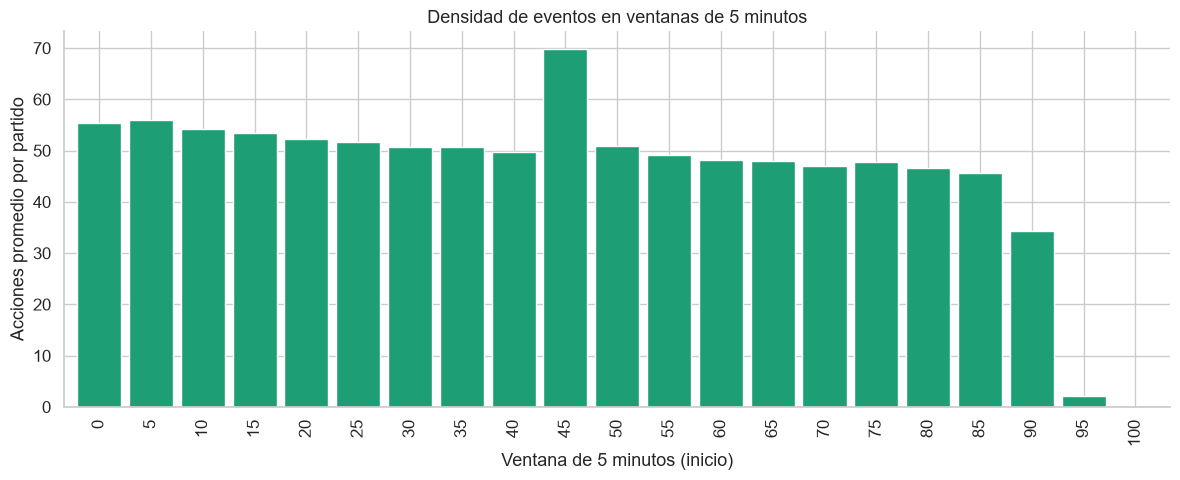

Ventanas con mayor actividad:
window_5min
45   69.7877
5    55.9377
0    55.3833
10   54.3035
15   53.4246
dtype: float64


In [68]:
# 3. Densidad de eventos en ventanas de 5 minutos (sugerencia del enunciado)
df_actions['window_5min'] = (df_actions['minute_bin'] // 5) * 5

intensity_5min = (
    df_actions.groupby('window_5min').size() / n_partidos
)

fig, ax = plt.subplots(figsize=(12, 5))
intensity_5min.plot(kind='bar', ax=ax, color='#1D9E75', width=0.85)
ax.set_xlabel('Ventana de 5 minutos (inicio)')
ax.set_ylabel('Acciones promedio por partido')
ax.set_title('Densidad de eventos en ventanas de 5 minutos')
ax.spines[['top', 'right']].set_visible(False)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print('Ventanas con mayor actividad:')
print(intensity_5min.sort_values(ascending=False).head(5))

In [69]:
# 4. Identificación de goles en SPADL
#    Un gol = acción de tipo 'shot' con resultado 'success'
#    (Nota: por la Decisión 6 de la sección 3.1, result_id en 'shot' es heurístico y
#     menos confiable, pero es el único indicador de gol disponible en SPADL)
goals = df_actions[
    (df_actions['type_name'] == 'shot') &
    (df_actions['result_name'] == 'success')
].copy()

print(f'Goles detectados: {len(goals):,}')
print(f'Partidos con al menos un gol detectado: {goals["game_id"].nunique():,} de {n_partidos}')

Goles detectados: 9,017
Partidos con al menos un gol detectado: 1,140 de 1140


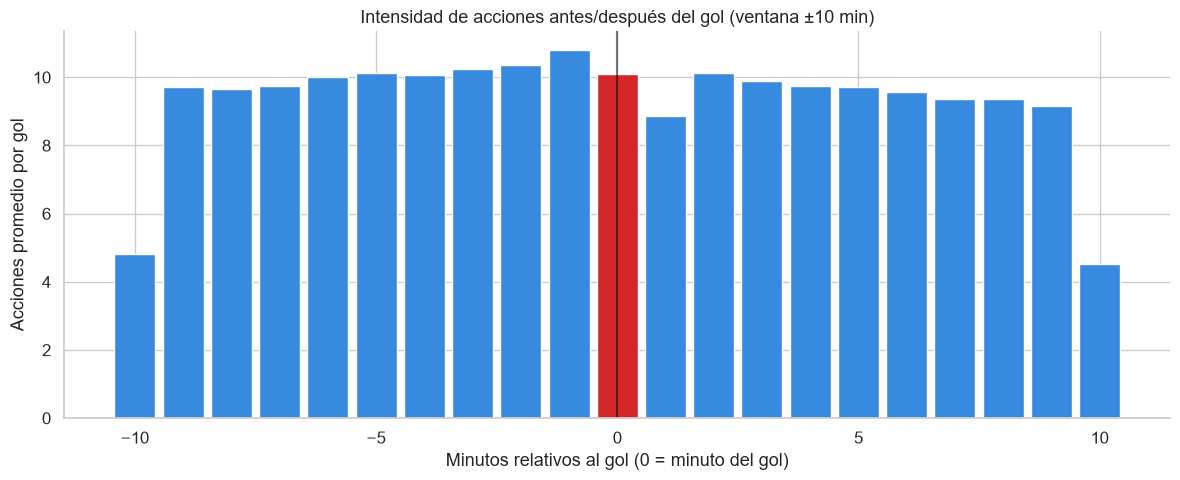

In [70]:
# 5. Patrón de actividad antes/después del gol
#    Para cada gol, tomamos una ventana de ±10 minutos alrededor del minuto del gol
#    y contamos acciones de ambos equipos en esa ventana, relativas al momento del gol (t=0)

VENTANA = 10  # minutos antes/después

pre_post_events = []

for _, goal in goals.iterrows():
    game_id = goal['game_id']
    goal_minute = goal['minute']

    game_actions = df_actions[
        (df_actions['game_id'] == game_id) &
        (df_actions['minute'] >= goal_minute - VENTANA) &
        (df_actions['minute'] <= goal_minute + VENTANA)
    ].copy()

    game_actions['minuto_relativo'] = (game_actions['minute'] - goal_minute).round().astype(int)
    pre_post_events.append(game_actions['minuto_relativo'])

minutos_relativos = pd.concat(pre_post_events)

# Densidad de acciones por minuto relativo al gol (t=0 = minuto del gol)
intensity_around_goal = minutos_relativos.value_counts().sort_index() / len(goals)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(
    intensity_around_goal.index, intensity_around_goal.values,
    color=['#d62728' if x == 0 else '#378ADD' for x in intensity_around_goal.index],
    width=0.85
)
ax.axvline(0, color='black', linestyle='-', alpha=0.5)
ax.set_xlabel('Minutos relativos al gol (0 = minuto del gol)')
ax.set_ylabel('Acciones promedio por gol')
ax.set_title(f'Intensidad de acciones antes/después del gol (ventana ±{VENTANA} min)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**Esto de de Claude no mío**


**Interpretación:**

- La intensidad de eventos a lo largo del partido muestra *(completar según gráfico: ¿picos al
  inicio de cada tiempo? ¿caída hacia el descanso? ¿aumento en el tramo final?)*.
- Las ventanas de 5 minutos con mayor actividad son *(completar con el resultado de
  `intensity_5min.sort_values()`)* — esto suele coincidir con el arranque de cada mitad, cuando
  los equipos tienen más energía y el balón está más en juego.
- Respecto al patrón antes/después del gol: *(completar — por ejemplo, ¿hay una caída de
  intensidad inmediatamente después del gol, consistente con el reinicio del juego (saque de
  mitad de cancha) y el "enfriamiento" táctico del equipo que anotó?)*.
- **Limitación metodológica:** la detección de goles usa `result_name == 'success'` sobre
  `type_name == 'shot'`, que según la Decisión 6 (sección 3.1) es heurística y no 100% confiable
  en la conversión Wyscout→SPADL. Esto puede introducir falsos positivos/negativos en el conteo
  de goles y, por lo tanto, ruido en el patrón temporal observado.


### Ejercicio 3 — Feature engineering avanzado
Implementá las siguientes features adicionales:
- `shot_zone`: zona del área desde donde se realizó el tiro (6 zonas estándar)
- `pressing_intensity`: número de duelos en los últimos 30 segundos
- `build_up_length`: longitud de la secuencia de pases antes de un tiro

### Ejercicio 4 — Sesgo posicional
Analizá si el número de acciones en SPADL está sesgado por posición.
¿Los delanteros tienen más acciones en el último tercio? ¿Los mediocampistas hacen más pases?
Graficá boxplots de las principales métricas por posición.

### Ejercicio 5 — Decisiones de curación
Basándote en el análisis anterior, documentá en un reporte las 5 decisiones más importantes
de curación para este dataset. Para cada decisión: ¿qué problema resolvió? ¿cuántos registros
afectó? ¿qué alternativas consideraste?

---
### **Entregable 4/9/26**: Notebook con EDA completo + reporte de decisiones de curación. PPT con donde se muestren los principales hallazgos encontrados en esos dos TPs.